In [1]:
import pandas as pd

data = pd.read_csv('notebook/data/income_cleandata.csv')
data.head()     # shows first 5 rows as a nice table


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,13,4,0,1,4,1,2174,0,40,38,0
1,50,5,13,2,3,0,4,1,0,0,13,38,0
2,38,3,9,0,5,1,4,1,0,0,40,38,0
3,53,3,7,2,5,0,2,1,0,0,40,38,0
4,28,3,13,2,9,5,2,0,0,0,40,4,0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set(rc={'figure.figsize':(15,8)})
pd.pandas.set_option('display.max_columns', None)


In [3]:
data = pd.read_csv('adult.csv')

In [4]:
data.head()     # shows first 5 rows as a nice table 

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
#replace name of columns . with _

#df = pd.read_csv('adult.csv') 
data.rename(columns={'education.num':'education_num',
                   'marital.status':'marital_status',
                   'capital.gain':'capital_gain',
                   'capital.loss':'capital_loss',
                   'hours.per.week':'hours_per_week',
                   'native.country':'native_country',
                   'income':'income'}, inplace=True) #true means change in original dataframe

data.to_csv('adult.csv', index=False) #don't save index column in csv file
print('Saved Successfully')

Saved Successfully


In [6]:
data.shape #row and columns in dataset 

(32561, 15)

In [7]:
data.columns #column names in dataset 

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [8]:
data.dtypes #data types of columns in dataset if not in correct format we can change it to correct format   

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [9]:
data.info() #summary of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [10]:
#checking for missing values isnull() show total value which is difficult to idnetify which column has missing values so we use sum() to get total number of missing values in each column
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [11]:
data.duplicated().sum() #check for duplicate values in dataset 

np.int64(24)

In [12]:
#drop duplicate values if there are any
data.drop_duplicates(inplace=True)
print(data['income'].value_counts())


income
<=50K    24698
>50K      7839
Name: count, dtype: int64


In [13]:
data.describe() #statistical summary of dataset

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [98]:
#seprate categorical and numerical columns
categorical_features = data.select_dtypes(include='object').columns
numerical_features = data.select_dtypes(exclude='object').columns
#exclude meaning target only numerical features
#include meaning target only categorical features
print(categorical_features)
print(numerical_features)

Index([], dtype='object')
Index(['age', 'workclass', 'education_num', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
       'hours_per_week', 'income'],
      dtype='object')


In [15]:
categorical_features

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [16]:
numerical_features

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [17]:
#value count works only for categorical features not for numerical features and work only 1 time so we use loop to apply value count on every categorical feature
#EDA exploratory data analysis that inform us about data and help us to find patterns in data and relationship between features and target variable
for i in categorical_features:
    print(i,data[i].unique())

    print()
    print('*****************************seperate columns*****************************')
    print()

workclass ['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']

*****************************seperate columns*****************************

education ['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']

*****************************seperate columns*****************************

marital_status ['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']

*****************************seperate columns*****************************

occupation ['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']

*****************************seperate columns*****************************


In [18]:
#replace ? columns, 1.delete 2.categoriacl data we find mode()
'''
data["workclass"] = data["workclass"].replace("?","Private")
data["occupation"] = data["occupation"].replace("?","Prof-specialty")
data["native-country"] = data["native-country"].replace("?","United-States")
'''

#calculate mode of each column and replace ? with mode value

workclass_mode = data["workclass"].replace("?",np.nan).mode()[0]
occupation_mode = data["occupation"].replace("?",np.nan).mode()[0]
country_mode = data["native_country"].replace("?",np.nan).mode()[0]

#show model value of each coulmn
print(f"workclass mode:{workclass_mode}")
print(f"occupation mode:{occupation_mode}")
print(f"native_country mode:{country_mode}")

#replace ? with calculated model value
data["workclass"] =data["workclass"].replace("?", workclass_mode)
data["occupation"] = data["occupation"].replace("?",occupation_mode)
data["native_country"] = data["native_country"].replace("?", country_mode)



workclass mode:Private
occupation mode:Prof-specialty
native_country mode:United-States


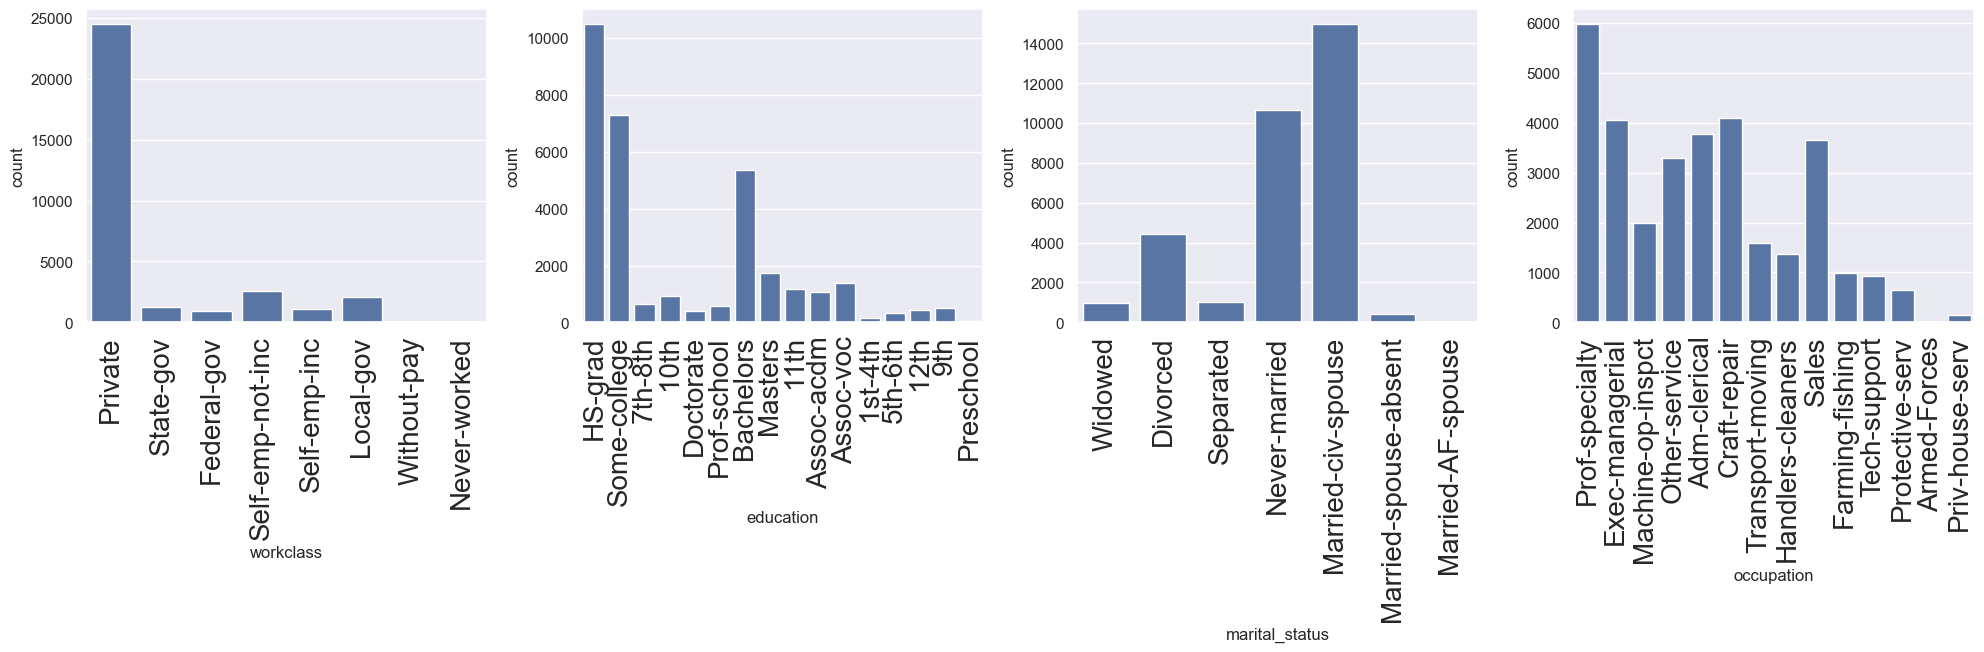

In [19]:
#data visualization
plt.style.use('fivethirtyeight')
sns.set(rc={"figure.figsize":(20,10)})
columns1 =['workclass','education','marital_status','occupation']

for i in range(0,len(columns1)):
    plt.subplot(2,4,i+1)
    sns.countplot(x=data[columns1[i]])
    plt.xticks(size=20, rotation=90)
    plt.tight_layout()


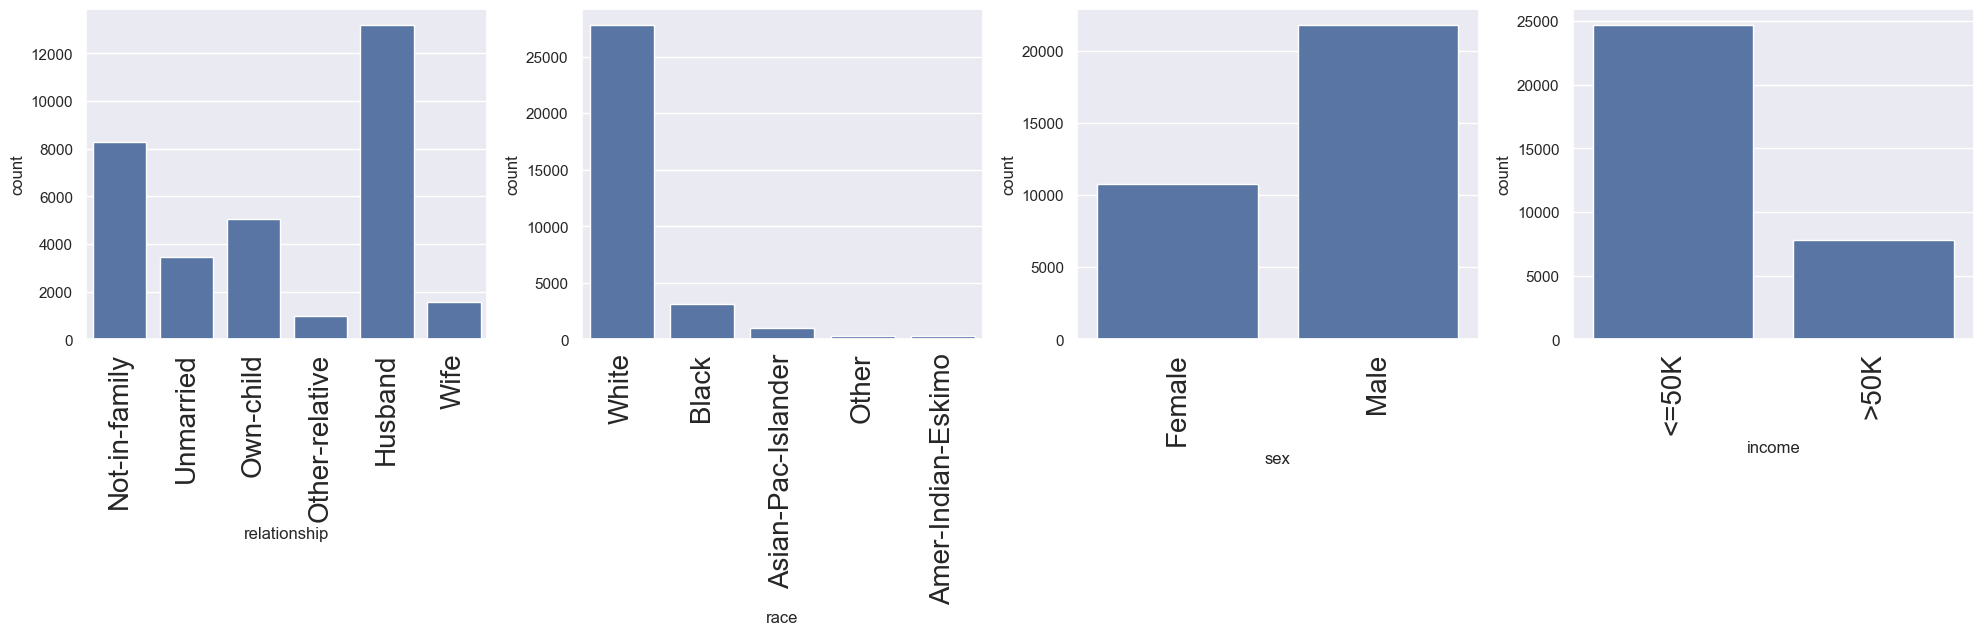

In [20]:
column2 =['relationship','race','sex','income'] 
for i in range(0, len(column2)):
    plt.subplot(2,4, i+1)
    sns.countplot(x=data[column2[i]])
    plt.xticks(size=20, rotation=90)
    plt.tight_layout()
          

In [21]:
#we are balancing income column because it is our target variable and it is imbalanced because there are more people with income less than 50k than people with income greater than 50k so we will use undersampling technique to balance the dataset

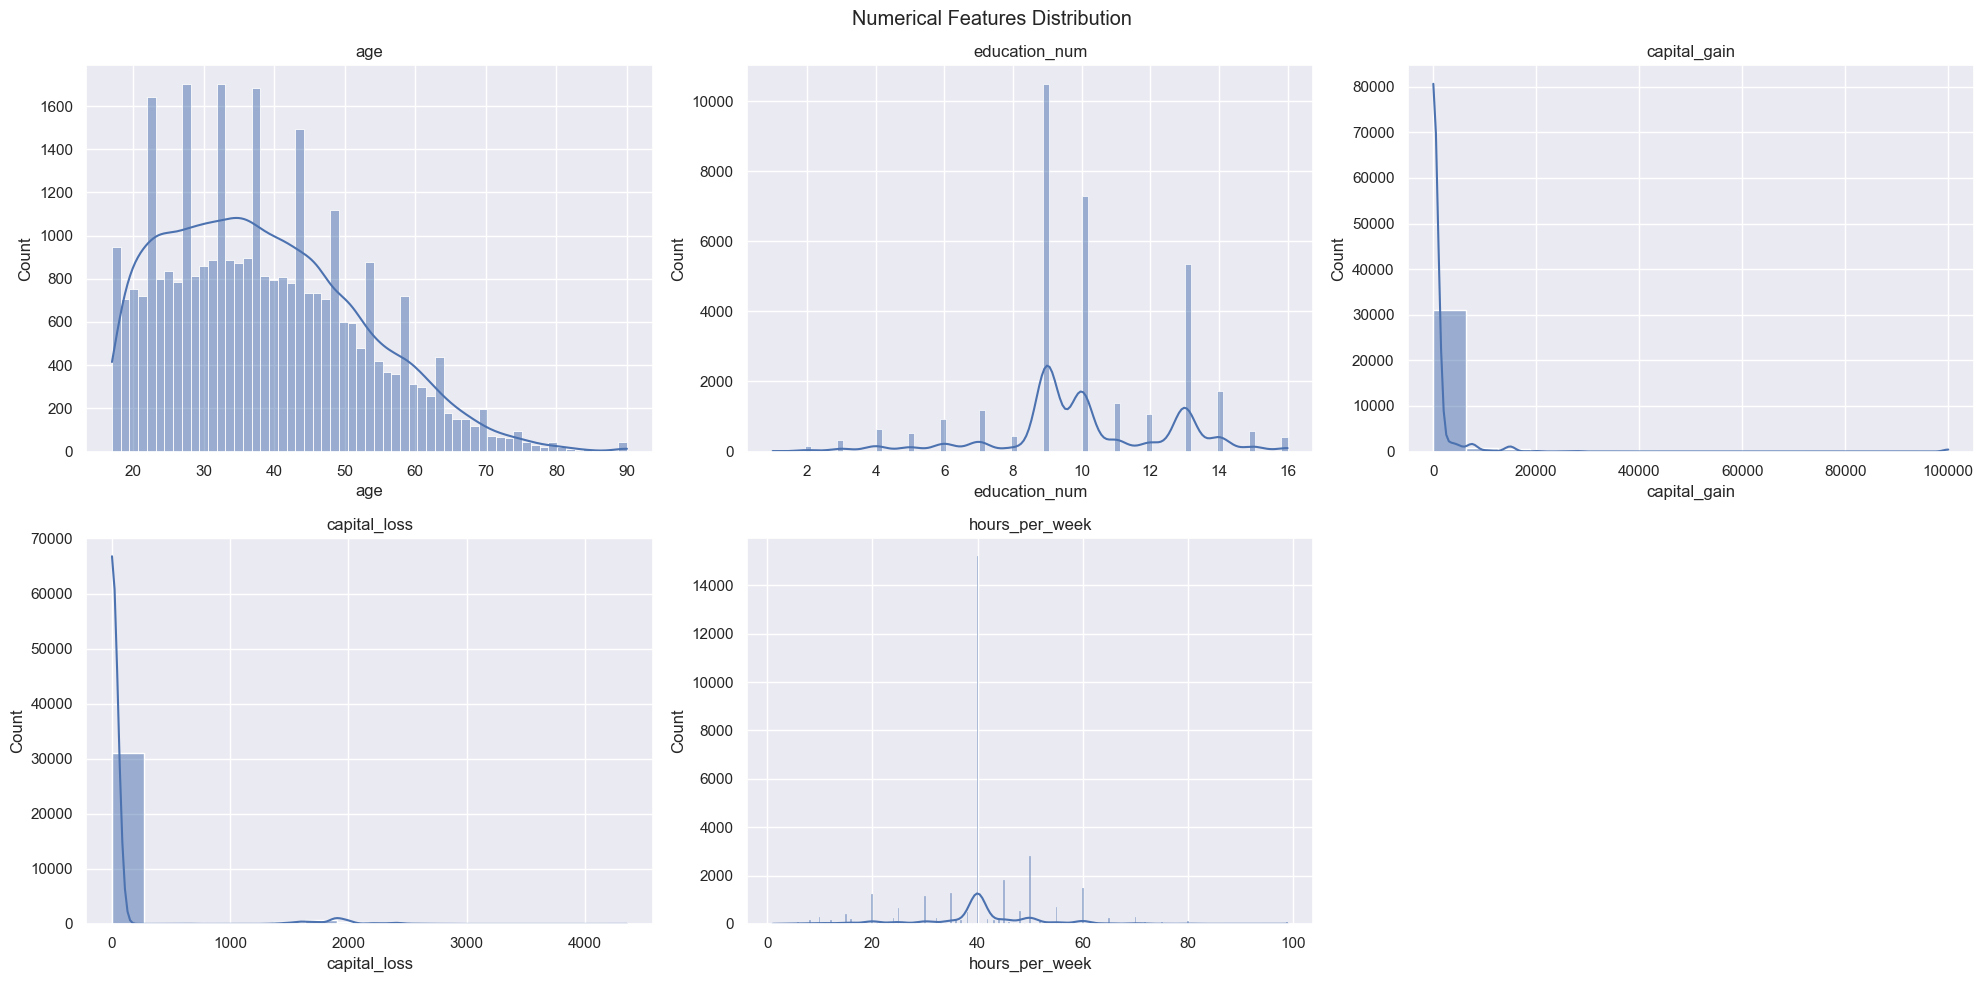

In [22]:
#distribution graph for numerical features
'''
plt.suptitle('Distribution graph of Numerical Features')
plt.figure(figsize=(16,5))
for i in range(0,len(numerical_features)):
    plt.subplot(2,4,i+1)
    sns.displot(x=data[numerical_features[i]])
    plt.xticks(size=15,rotation=90)
    plt.tight_layout() 
     
      Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
        

# Age distribution
plt.suptitle('Age Distribution Graph')
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data['age'], kde=True)  # ✅ histplot + kde
plt.tight_layout()
plt.show()

# Education num distribution
plt.figure(figsize=(16,5))
plt.suptitle('Education Num Distribution Graph')
sns.histplot(data['education_num'], kde=True)
plt.tight_layout()
plt.show()

# Capital gain distribution
plt.figure(figsize=(16,5))
plt.suptitle('Capital Gain Distribution Graph')
sns.histplot(data['capital_gain'], kde=True)
plt.tight_layout()
plt.show()

# Capital loss distribution
plt.figure(figsize=(16,5))
plt.suptitle('Capital Loss Distribution Graph')
sns.histplot(data['capital_loss'], kde=True)
plt.tight_layout()
plt.show()

# Hours per week distribution
plt.figure(figsize=(16,5))
plt.suptitle('Hours Per Week Distribution Graph')
sns.histplot(data['hours_per_week'], kde=True)
plt.tight_layout()
plt.show()


numerical_features = ['age', 'education_num', 
                       'capital_gain', 'capital_loss', 
                       'hours_per_week']

for col in numerical_features:
    plt.figure(figsize=(10,4))
    sns.histplot(data[col], kde=True) 
    plt.title(f'{col} Distribution')
    plt.tight_layout()
    plt.show()'''

numerical_features = ['age', 'education_num',
                       'capital_gain', 'capital_loss',
                       'hours_per_week']

# ONE figure created ONCE outside loop!
plt.figure(figsize=(20,10))
plt.suptitle('Numerical Features Distribution')

for i in range(len(numerical_features)):
    plt.subplot(2, 3, i+1)          # position in grid
    sns.histplot(data[numerical_features[i]], kde=True)
    plt.title(numerical_features[i]) # title for each
    plt.tight_layout()

plt.show()  # show ONCE at the end


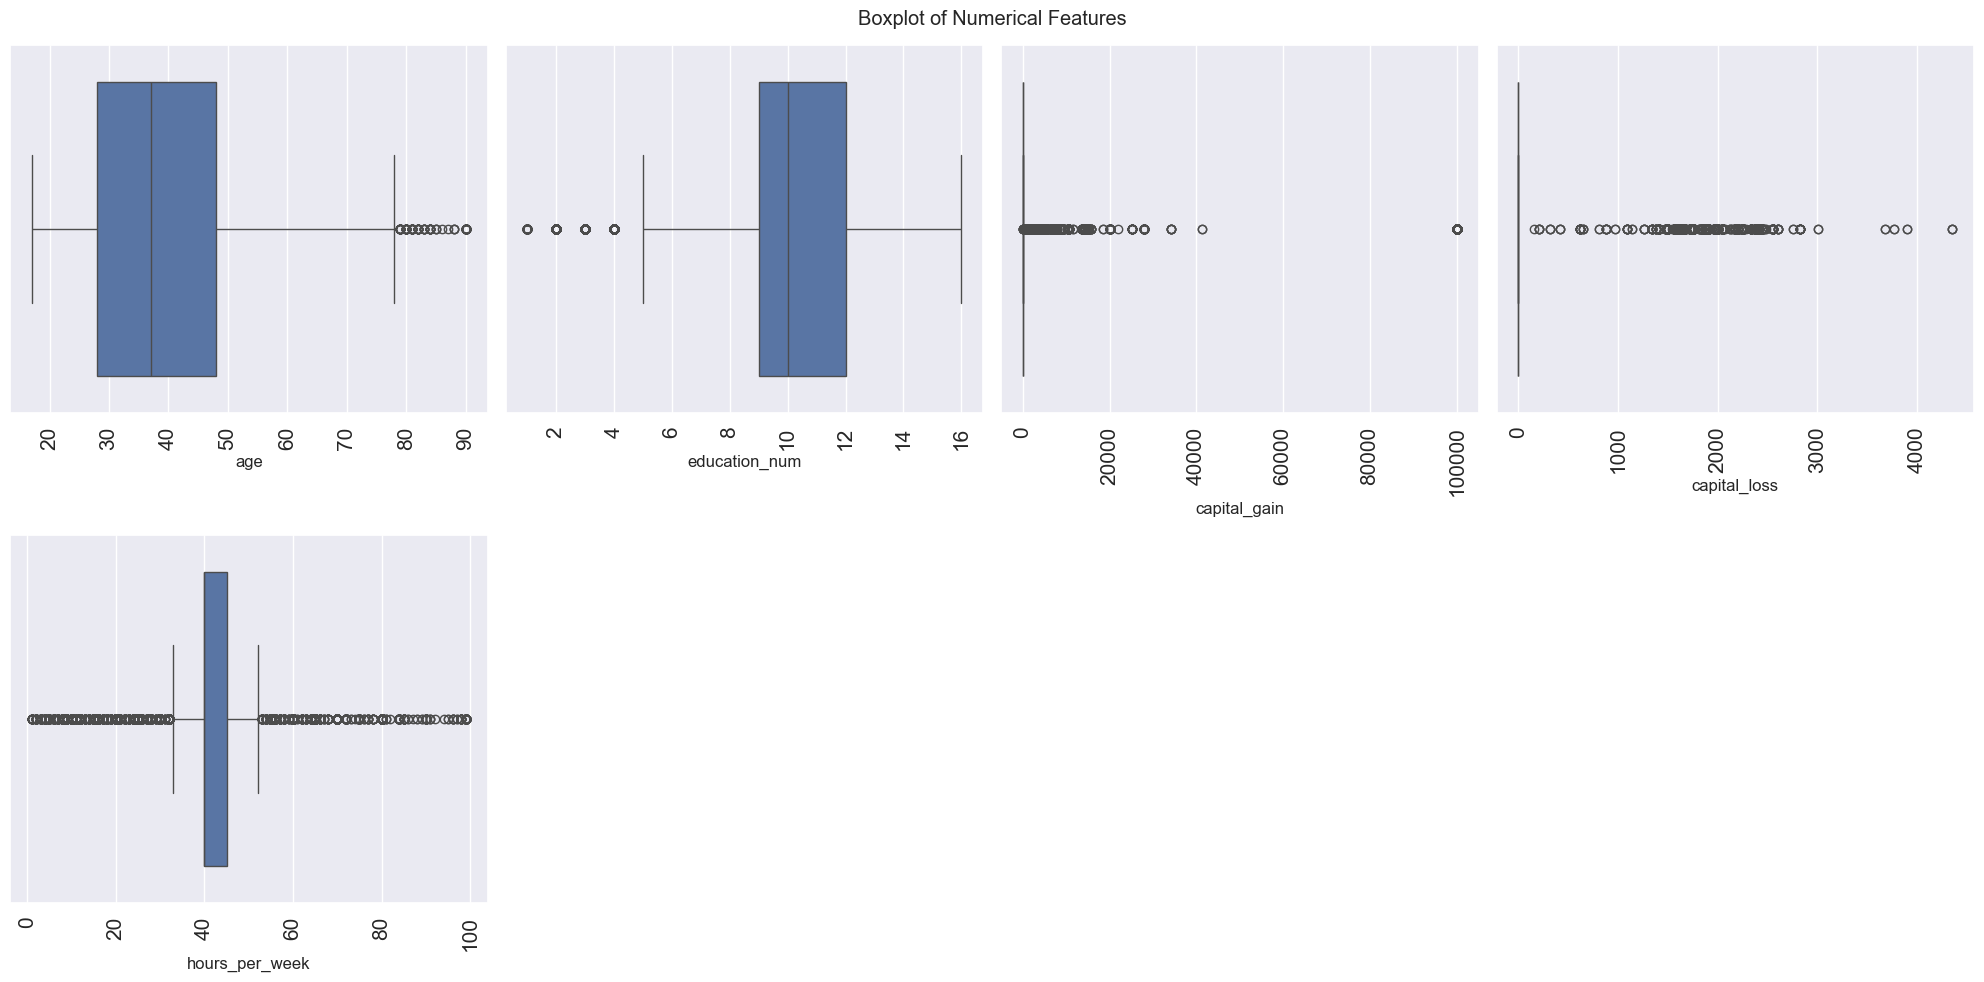

In [23]:
#check outlier in our data using boxplot
plt.suptitle('Boxplot of Numerical Features')
for i in range(0,len(numerical_features)):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=data[numerical_features[i]])
    plt.xticks(size=15,rotation=90)
    plt.tight_layout()  


<Axes: xlabel='income'>

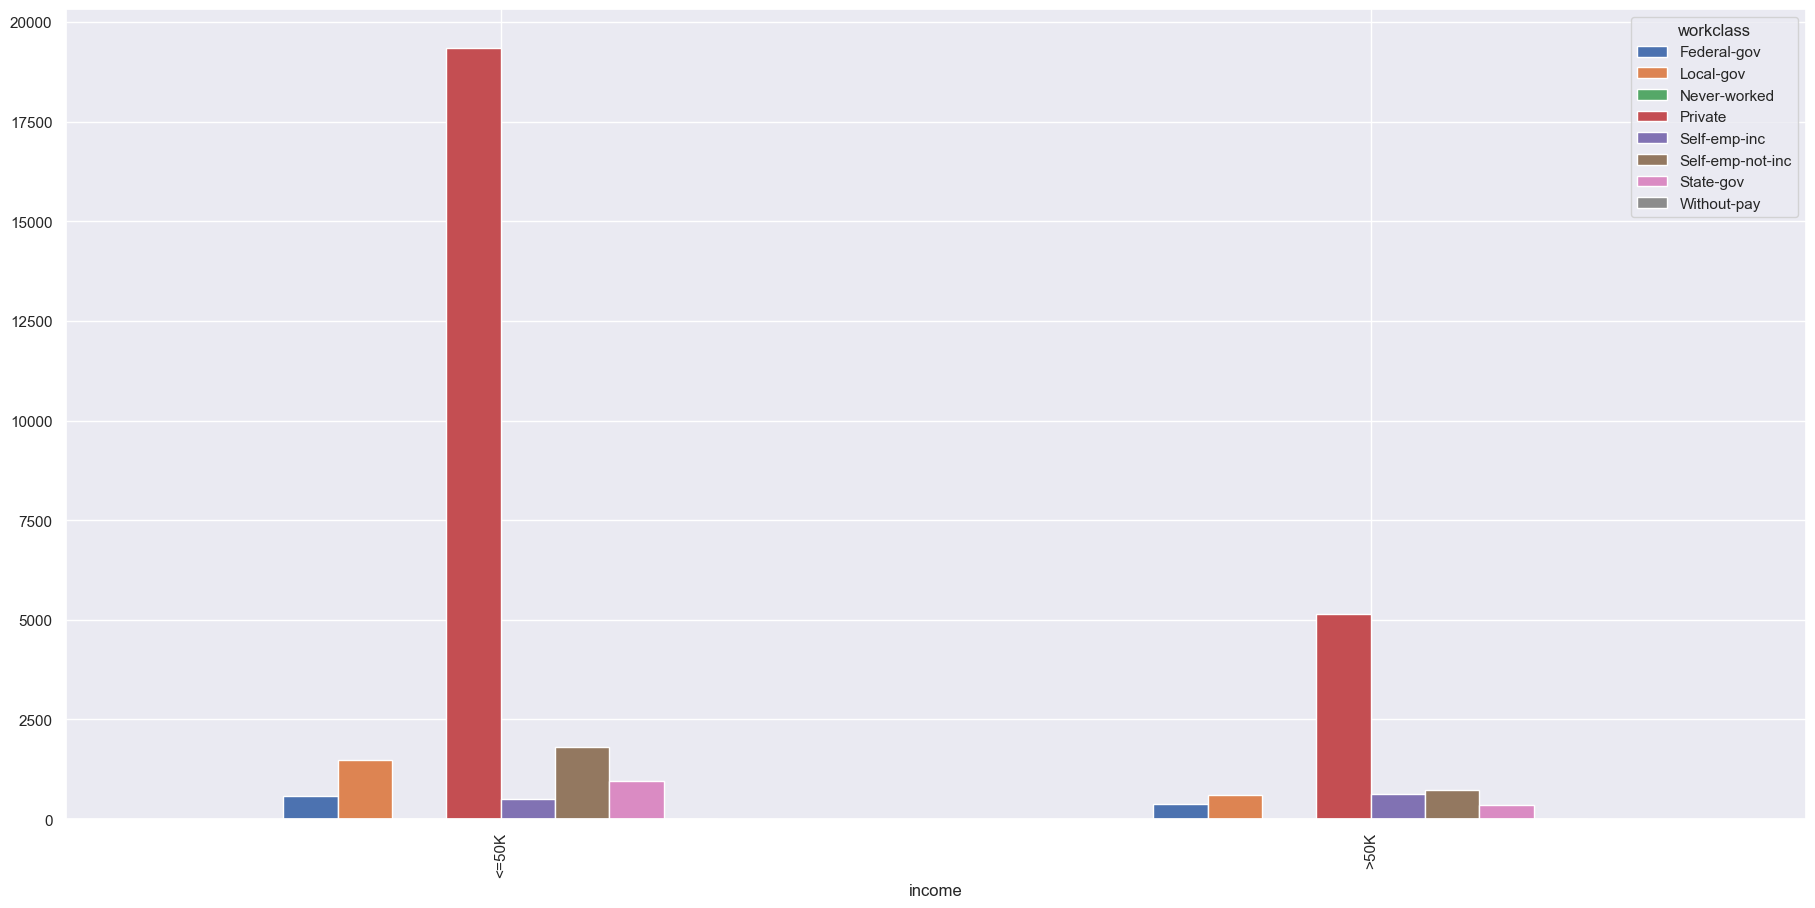

In [24]:
salary = pd.crosstab(data['income'],data['workclass'])
salary.plot(kind='bar')

<Axes: xlabel='income'>

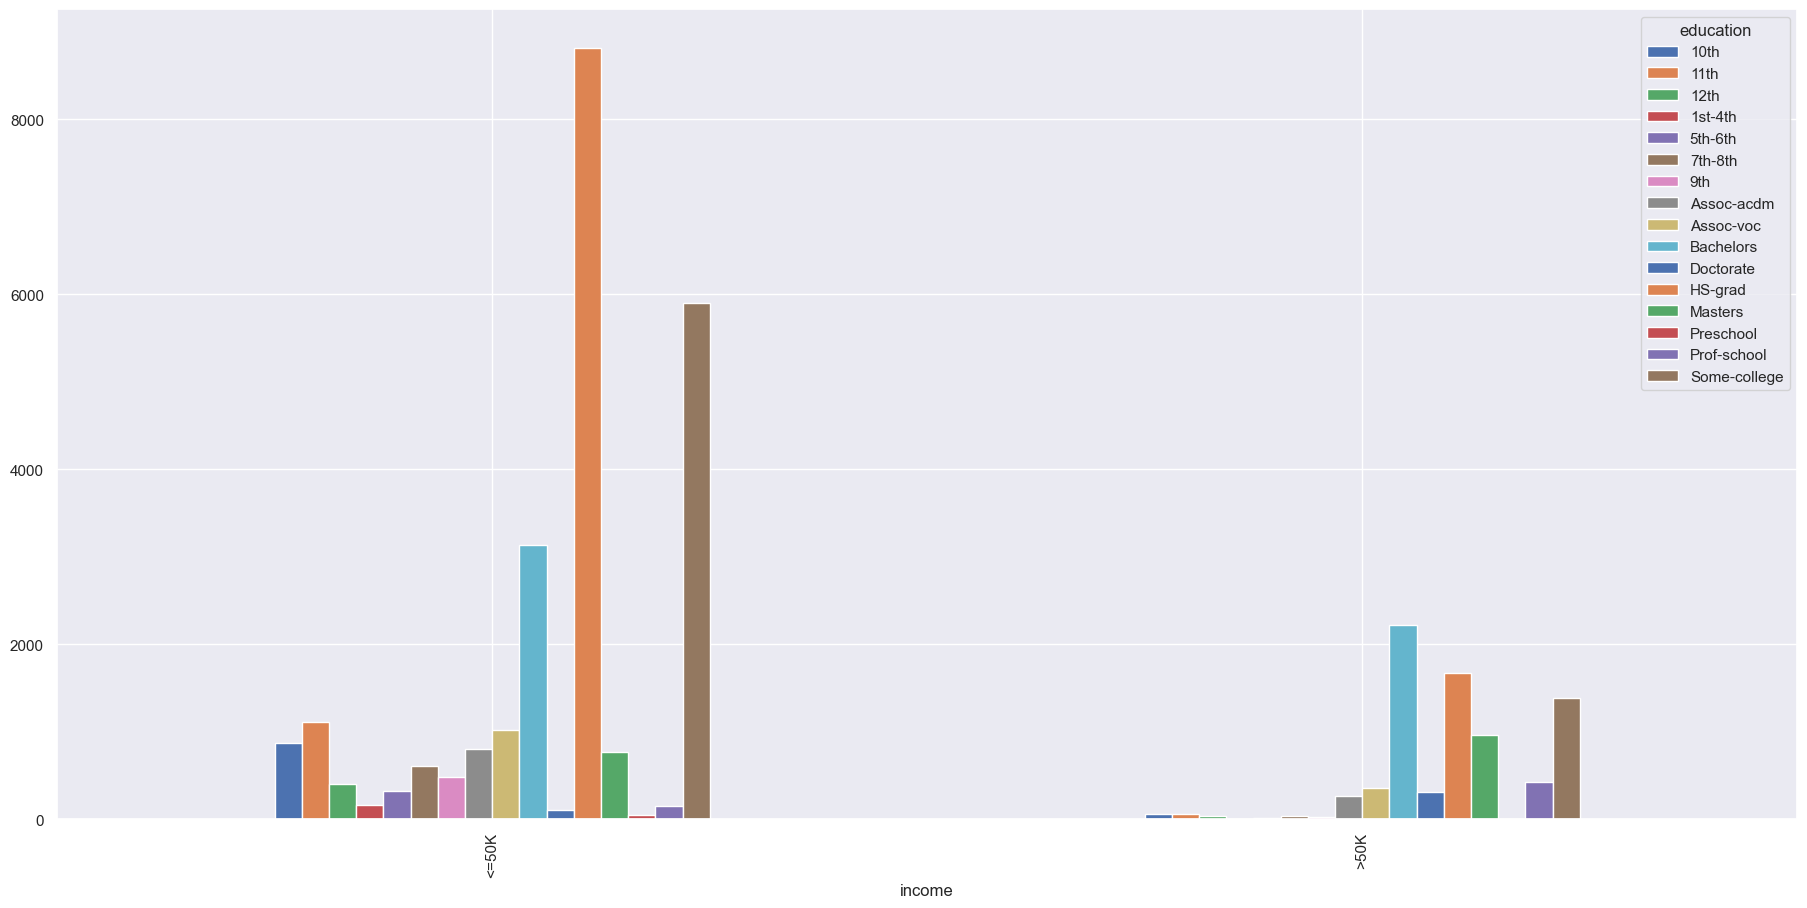

In [25]:
salary = pd.crosstab(data['income'],data['education'])
salary.plot(kind='bar')

<Axes: xlabel='income'>

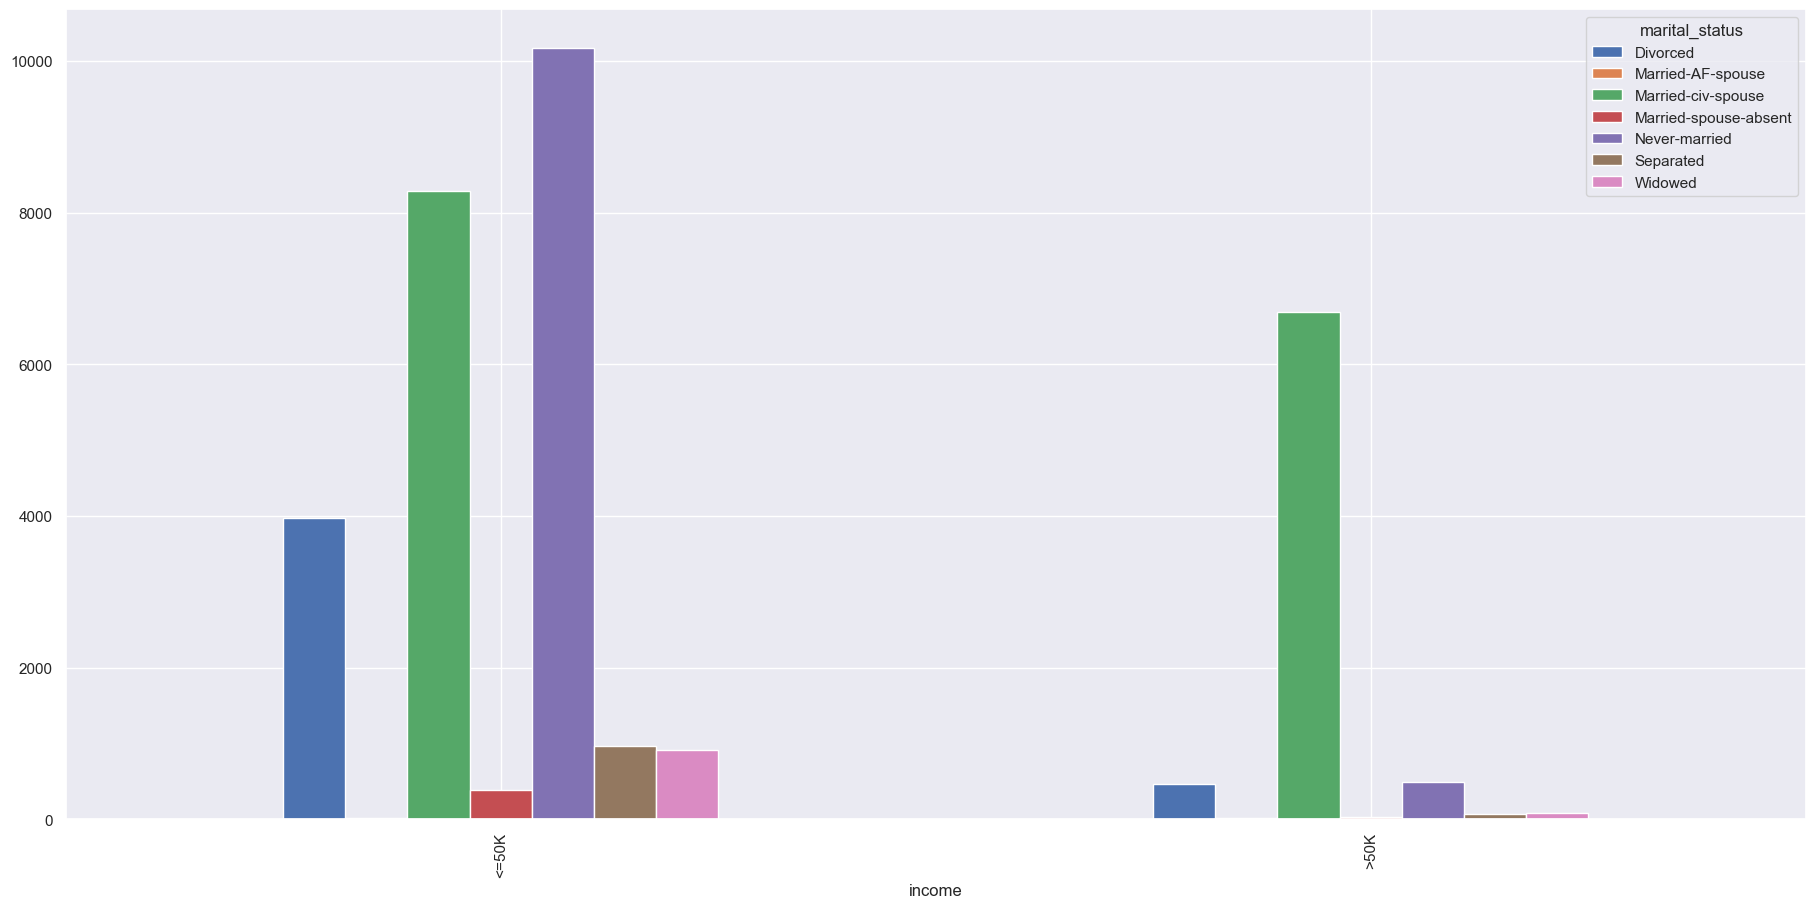

In [26]:
salary = pd.crosstab(data['income'],data['marital_status'])
salary.plot(kind='bar')

<Axes: xlabel='income'>

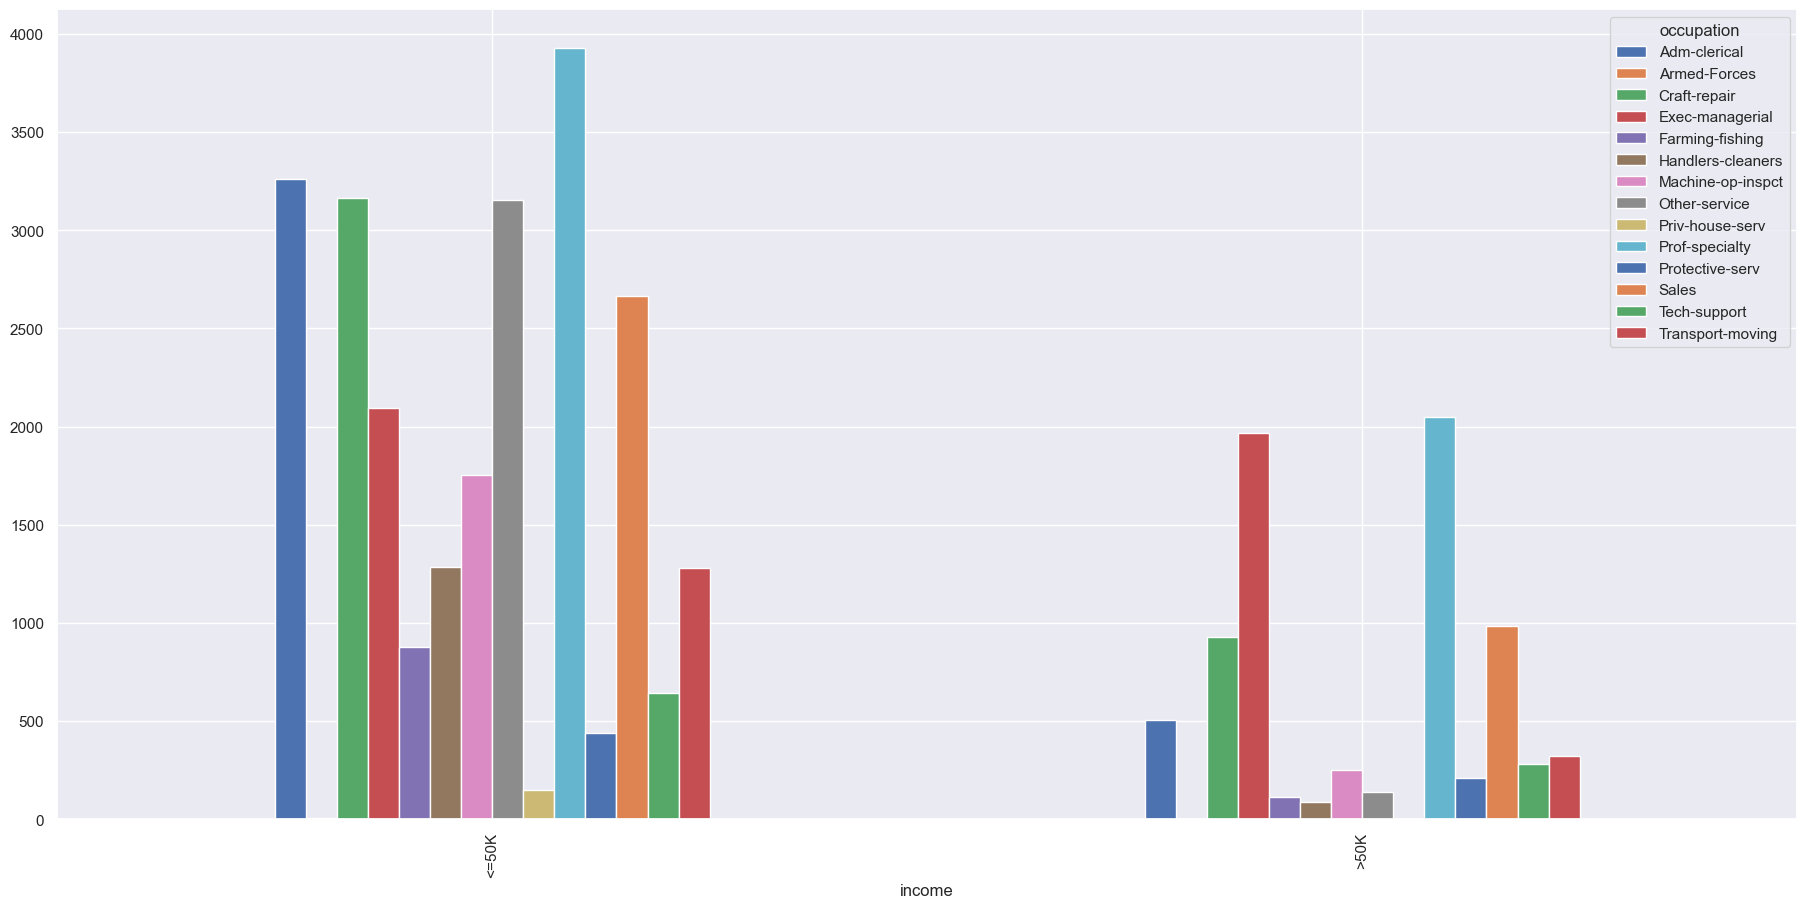

In [27]:
salary = pd.crosstab(data['income'],data['occupation'])
salary.plot(kind='bar')

<Axes: xlabel='income'>

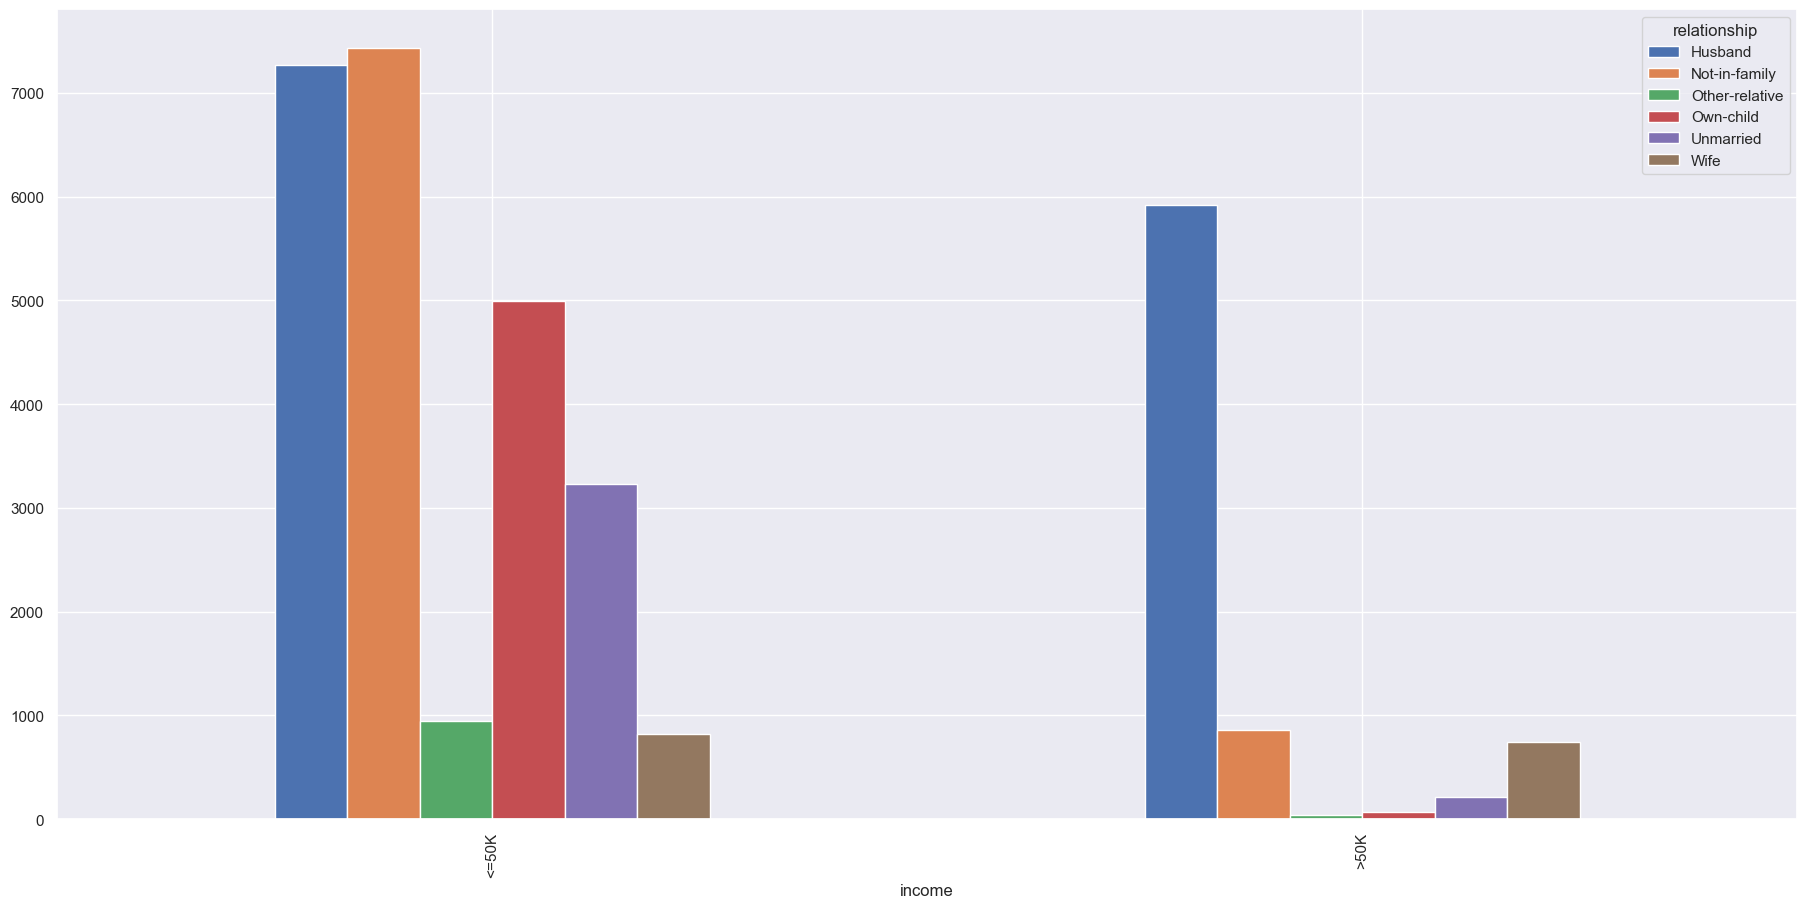

In [28]:
salary = pd.crosstab(data['income'],data['relationship'])
salary.plot(kind='bar')

<Axes: xlabel='income'>

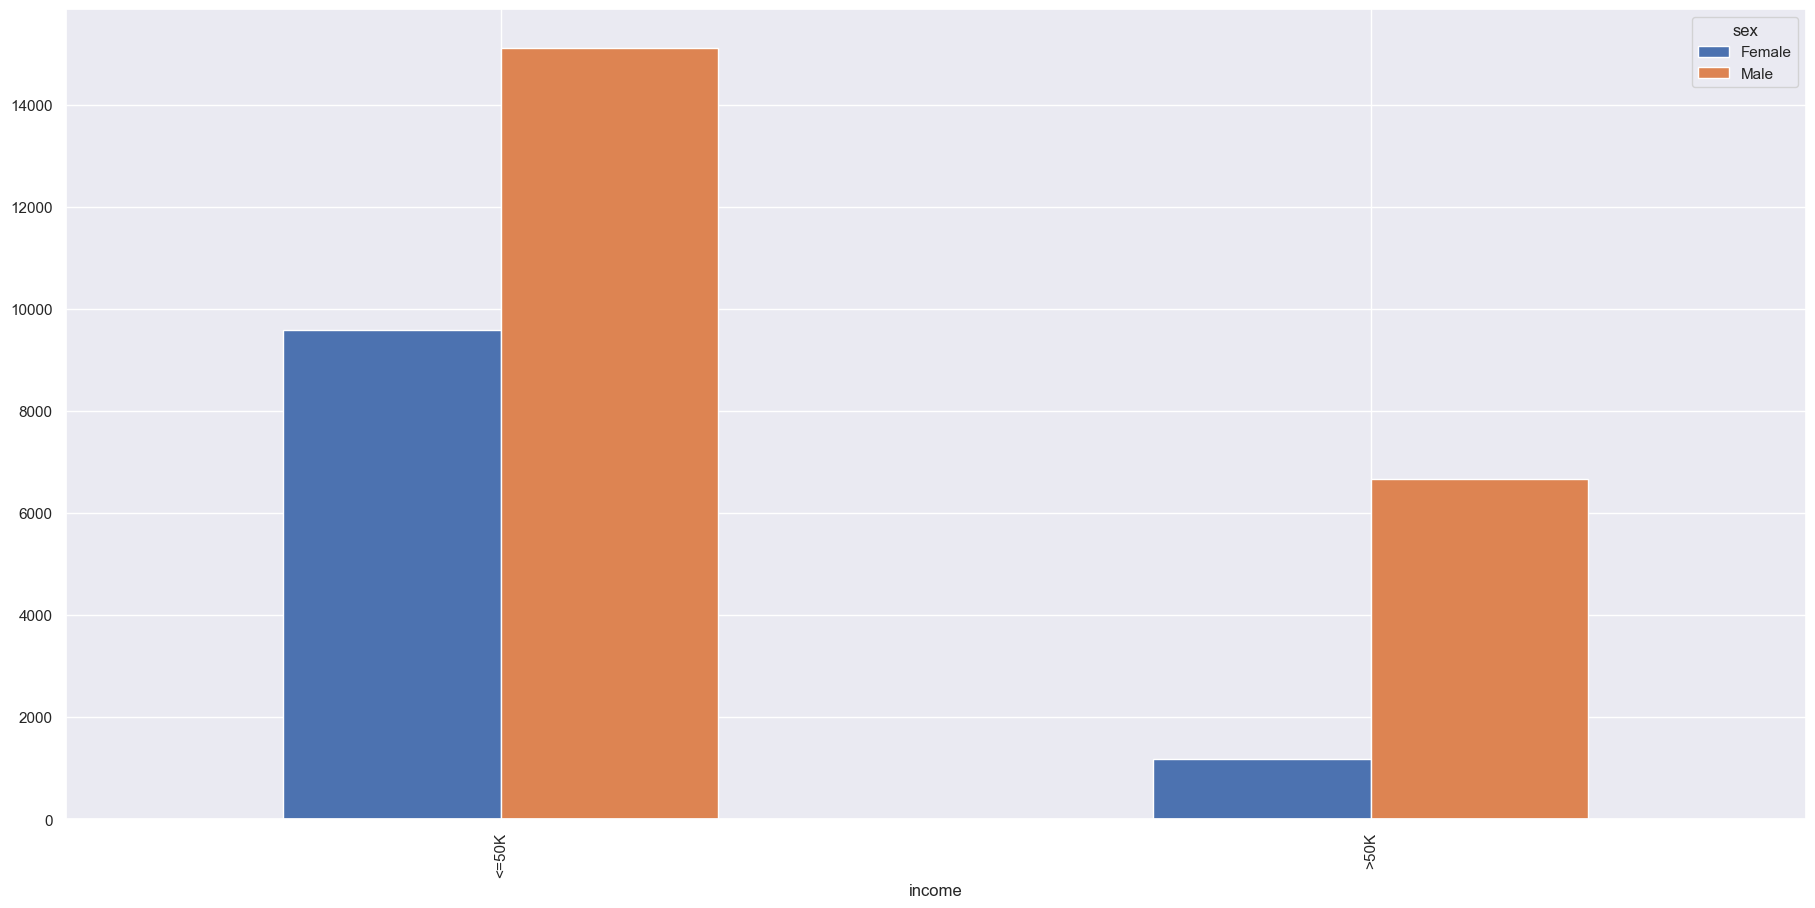

In [29]:
salary = pd.crosstab(data['income'],data['sex'])
salary.plot(kind='bar')

In [30]:
#how income is categorical data? because it has two categories <=50K and >50K and it is our target variable and we will use it to predict whether a person has income less than or greater than 50k based on other features in dataset
categorical_features

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [31]:
#convert categorical data to numerical data using label encoding because machine learning algorithms can only understand numerical data and not categorical data
from sklearn.preprocessing import LabelEncoder
#create label encoder object
le = LabelEncoder()
#define categorical feature
categorical_features = ["workclass","education","marital_status","occupation","sex","race","relationship","native_country"]
#loop through each categorical feature and apply label encoding
for feature in categorical_features:
    le.fit(data[feature])
    data[feature] = le.transform(data[feature])
    
print(data['income'].value_counts())


income
<=50K    24698
>50K      7839
Name: count, dtype: int64


In [32]:
# Run these checks one by one

# Check 1 - What does income look like RIGHT NOW?
print(data['income'].unique())

# Check 2 - What type is income?
print(data['income'].dtype)

# Check 3 - First 5 values
print(data['income'].head())

['<=50K' '>50K']
object
0    <=50K
1    <=50K
2    <=50K
3    <=50K
4    <=50K
Name: income, dtype: object


In [33]:
#assign 0 and 1 to target variable income column <=50K as 0 and >50K as 1
data["income"] = data["income"].map({'<=50K':0,'>50K':1})
print(data['income'].value_counts())

income
0    24698
1     7839
Name: count, dtype: int64


<Axes: >

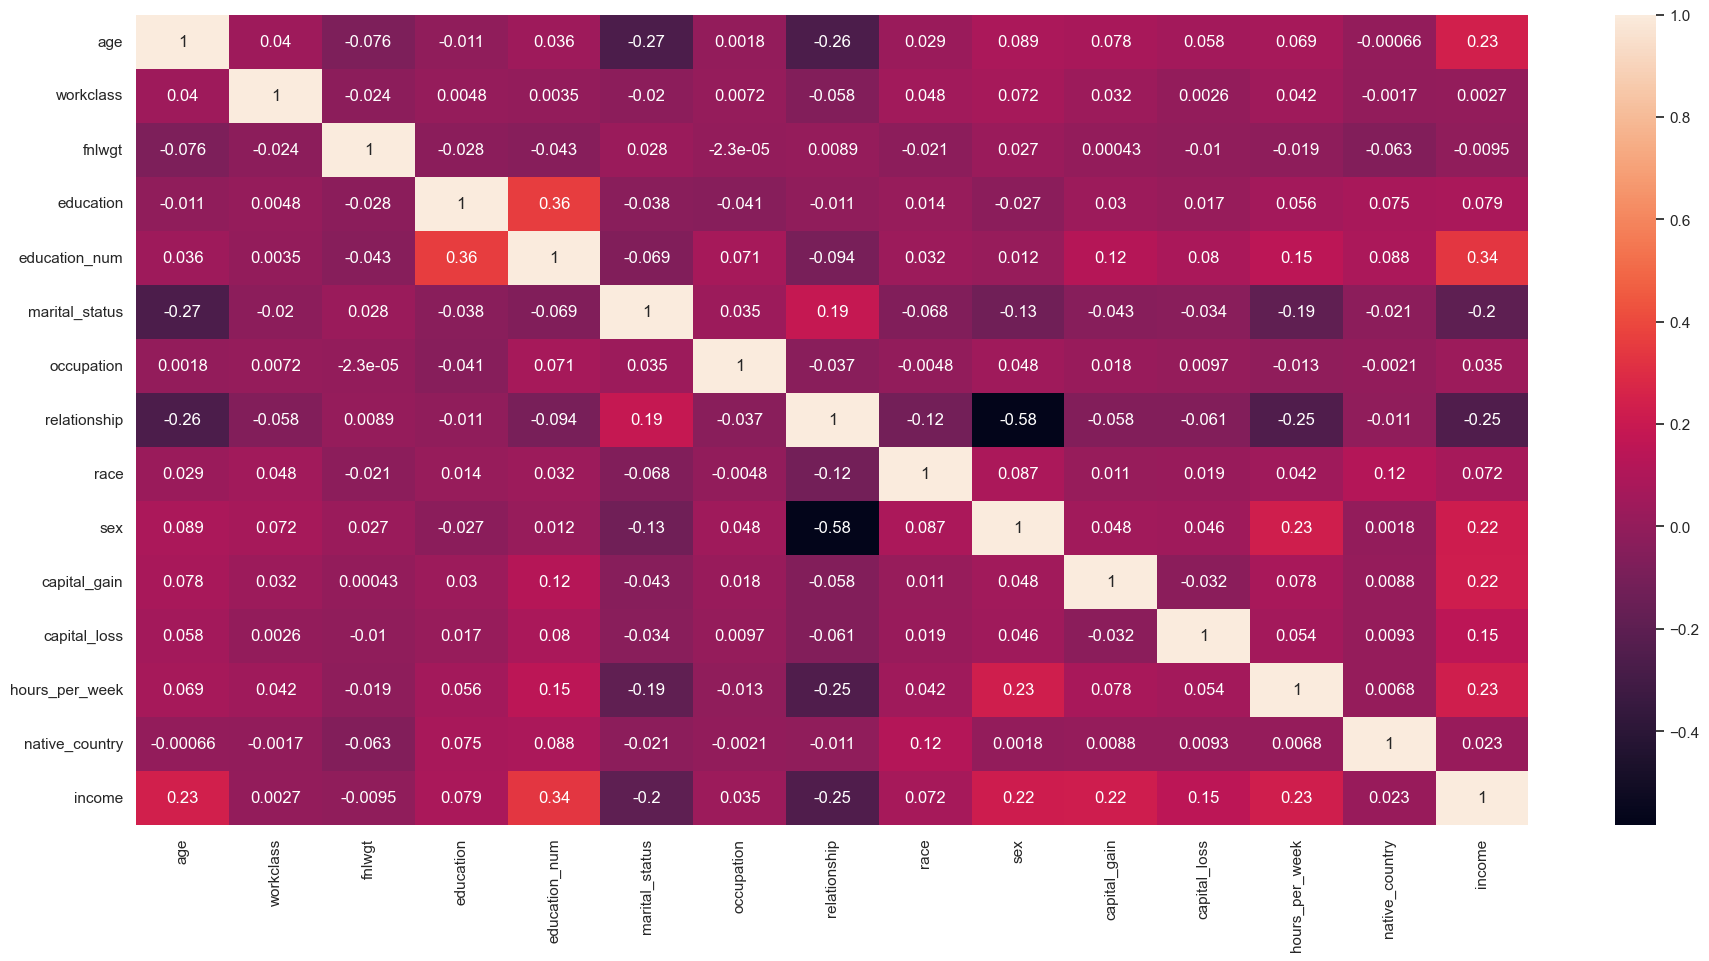

In [34]:
sns.heatmap(data.corr(),annot=True)

In [35]:
#check distribution of target variable income 0 and 1
data['income'].value_counts()

income
0    24698
1     7839
Name: count, dtype: int64

In [36]:
#data drop education because it is highly correlated with education_num and it is also not important for our model because it has many categories and it will increase the complexity of our model and it will also increase the training time of our model

data.drop(["education","fnlwgt","native_country"],axis=1,inplace=True)

In [37]:
data.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income
0,90,3,9,6,9,1,4,0,0,4356,40,0
1,82,3,9,6,3,1,4,0,0,4356,18,0
2,66,3,10,6,9,4,2,0,0,4356,40,0
3,54,3,4,0,6,4,4,0,0,3900,40,0
4,41,3,10,5,9,3,4,0,0,3900,40,0


In [38]:
#Apply Z-score on hpw as it is a normal distributed not skwed so Z-score will help to detect and remove outliers in hours_per_week column
print("mean value of hpw",data['hours_per_week'].mean())
print("std value of hpw",data['hours_per_week'].std())
print("min value of hpw",data['hours_per_week'].min())
print("max value of hpw",data['hours_per_week'].max())


mean value of hpw 40.44032947106371
std value of hpw 12.346889182125146
min value of hpw 1
max value of hpw 99


In [39]:
#find outlier boundaries 
print("Height allowed",data['hours_per_week'].mean()+ 3*data['hours_per_week'].std())
print("lowest allowed",data['hours_per_week'].mean()- 3*data['hours_per_week'].std())


Height allowed 77.48099701743915
lowest allowed 3.3996619246882744


In [40]:
#find outlier according to boundary define
data[(data['hours_per_week'] > 77.5) | (data['hours_per_week'] < 3.39)]

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income
29,38,3,6,4,9,1,4,1,0,2559,90,1
81,60,4,15,2,9,0,4,1,0,2415,80,1
92,39,3,10,2,4,0,4,1,0,2415,99,1
96,46,5,15,2,9,0,4,1,0,2415,80,1
98,39,3,15,2,11,0,4,1,0,2415,99,1
...,...,...,...,...,...,...,...,...,...,...,...,...
32476,58,4,16,4,9,1,4,0,0,0,99,0
32482,35,3,8,2,2,0,4,1,0,0,84,0
32500,82,3,9,4,9,1,4,1,0,0,3,0
32528,81,3,11,0,9,4,4,0,0,0,1,0


In [41]:
#we can apply trimming but out outlier are more and it will thin our data
# new_df = data[(data['hours_per_week'] < 77.5 ) & (data['hours_per_week'] > 3.39)]
# new_df

In [42]:
#new column generate where each value subtract from mean and will divide  standard deviation
#calculate z score
data['hour_per_week'] = (data['hours_per_week'] - data['hours_per_week'].mean())/data['hours_per_week'].std()
#and will keep within define boundary
data[data['hour_per_week'] < -3 ]
data[(data['hour_per_week'] > 3 ) | (data['hour_per_week'] < -3)]

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income,hour_per_week
29,38,3,6,4,9,1,4,1,0,2559,90,1,4.013940
81,60,4,15,2,9,0,4,1,0,2415,80,1,3.204019
92,39,3,10,2,4,0,4,1,0,2415,99,1,4.742868
96,46,5,15,2,9,0,4,1,0,2415,80,1,3.204019
98,39,3,15,2,11,0,4,1,0,2415,99,1,4.742868
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32476,58,4,16,4,9,1,4,0,0,0,99,0,4.742868
32482,35,3,8,2,2,0,4,1,0,0,84,0,3.527987
32500,82,3,9,4,9,1,4,1,0,0,3,0,-3.032369
32528,81,3,11,0,9,4,4,0,0,0,1,0,-3.194354


In [43]:
#CAPPING
upper_limit = data['hours_per_week'].mean() +3*data['hours_per_week'].std()
lower_limit = data['hours_per_week'].mean() -3*data['hours_per_week'].std()
print("upper limit",upper_limit)
print("lower limit",lower_limit)

upper limit 77.48099701743915
lower limit 3.3996619246882744


In [44]:
#np.where(x=condition , y=if condition true-->next, z=if condition false-->next)
#new_data_cap = data.copy()

data['hours_per_week'] = np.where(
   data['hours_per_week'] > upper_limit, upper_limit,
    np.where(
     data['hours_per_week'] < lower_limit, lower_limit,
     data['hours_per_week']
     )
)

In [45]:
data['hours_per_week'].describe()

count    32537.000000
mean        40.336947
std         11.938468
min          3.399662
25%         40.000000
50%         40.000000
75%         45.000000
max         77.480997
Name: hours_per_week, dtype: float64

In [46]:
#data = data.drop('hour_per_week', axis=1)
data.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income,hour_per_week
0,90,3,9,6,9,1,4,0,0,4356,40.0,0,-0.035663
1,82,3,9,6,3,1,4,0,0,4356,18.0,0,-1.817489
2,66,3,10,6,9,4,2,0,0,4356,40.0,0,-0.035663
3,54,3,4,0,6,4,4,0,0,3900,40.0,0,-0.035663
4,41,3,10,5,9,3,4,0,0,3900,40.0,0,-0.035663


<Figure size 2000x1000 with 0 Axes>

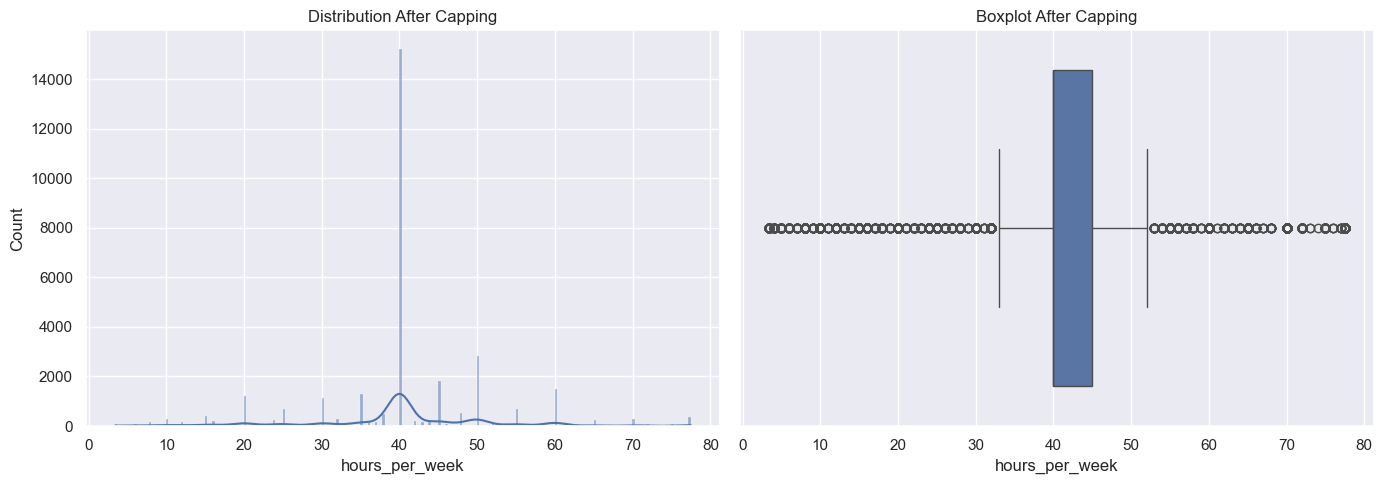

In [47]:
plt.suptitle('Hours Per Week - Before vs After Capping')

# Store original for comparison
# (run this BEFORE step 5 if you want comparison!)
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(data['hours_per_week'], kde=True)
plt.title('Distribution After Capping')

plt.subplot(1, 2, 2)
sns.boxplot(x=data['hours_per_week'])
plt.title('Boxplot After Capping')

plt.tight_layout()
plt.show()

In [48]:
print(data['income'].value_counts())

income
0    24698
1     7839
Name: count, dtype: int64


In [49]:
data['age'].skew() #check skewness of age column

np.float64(0.5576631514973126)

In [50]:
data['capital_gain'].skew() #check skewness of capital_gain column  

np.float64(11.949402833551476)

In [51]:
data['capital_loss'].skew() #check skewness of capital_loss column

np.float64(4.592702423271815)

<Axes: xlabel='age', ylabel='Count'>

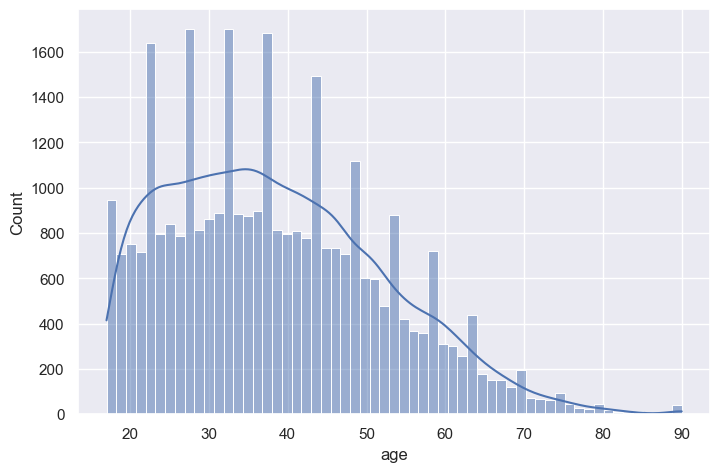

In [52]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data['age'], kde=True)  # ✅ histplot + kde

In [53]:
print("Mean value of age", data['age'].mean())
print("Std value of age", data['age'].std())
print("Max value of age", data['age'].max())
print("Min value of age", data['age'].min())


Mean value of age 38.585548759873376
Std value of age 13.637983518469902
Max value of age 90
Min value of age 17


In [54]:
data['age'].describe()

count    32537.000000
mean        38.585549
std         13.637984
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

<Axes: xlabel='age'>

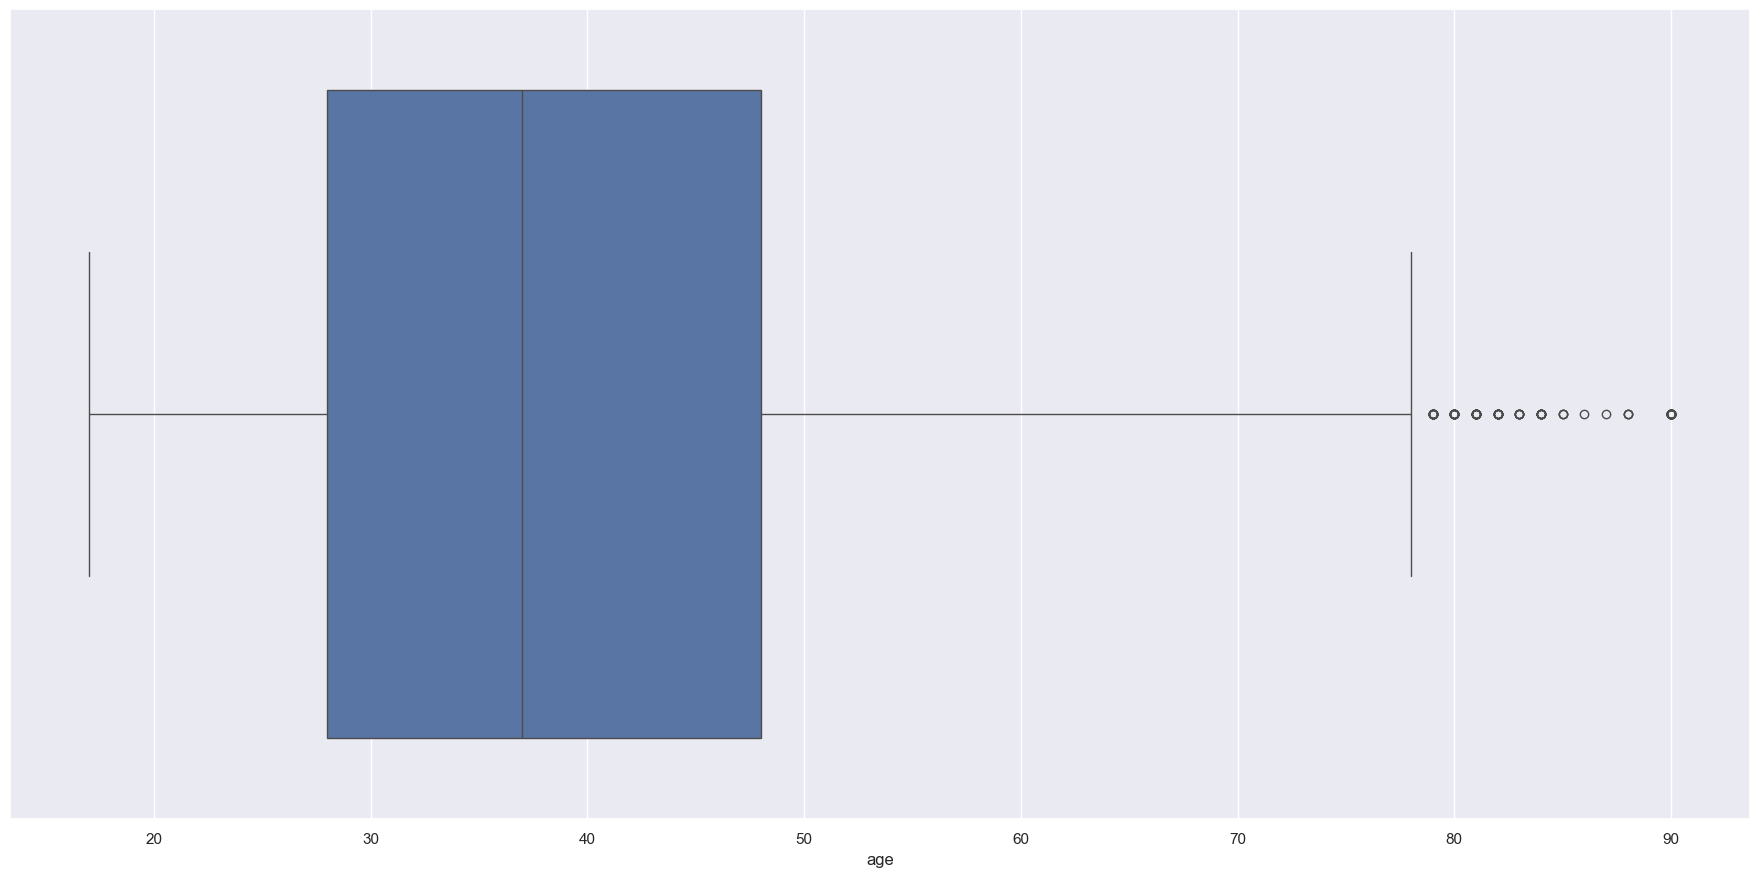

In [55]:
sns.boxplot(x=data['age'])

In [56]:
#calculate IQR of age column
percentile25 = data['age'].quantile(0.25)
percentile75 = data['age'].quantile(0.75)

In [57]:
percentile25, percentile75

(np.float64(28.0), np.float64(48.0))

In [58]:
iqr = percentile75 - percentile25
iqr

np.float64(20.0)

In [59]:
#define limit
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [60]:
print("Lower limit", lower_limit)
print("Upper limit", upper_limit)

Lower limit -2.0
Upper limit 78.0


In [61]:
data[data['age'] > upper_limit]

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income,hour_per_week
0,90,3,9,6,9,1,4,0,0,4356,40.000000,0,-0.035663
1,82,3,9,6,3,1,4,0,0,4356,18.000000,0,-1.817489
118,83,4,13,2,3,0,4,1,0,2392,55.000000,1,1.179218
128,81,3,9,2,3,0,4,1,0,2377,26.000000,1,-1.169552
199,90,3,9,4,7,1,2,1,0,2206,40.000000,0,-0.035663
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31939,82,5,9,2,4,0,4,1,0,0,20.000000,0,-1.655504
32305,90,3,9,6,0,4,4,0,0,0,25.000000,0,-1.250544
32468,85,3,13,2,3,0,4,1,0,0,3.399662,0,-3.032369
32500,82,3,9,4,9,1,4,1,0,0,3.399662,0,-3.032369


In [62]:
data[data['age'] < lower_limit]

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income,hour_per_week


In [63]:
new_data = data[(data['age'] < upper_limit) & (data['age'] > lower_limit)]
new_data.shape

(32372, 13)

<Axes: xlabel='age'>

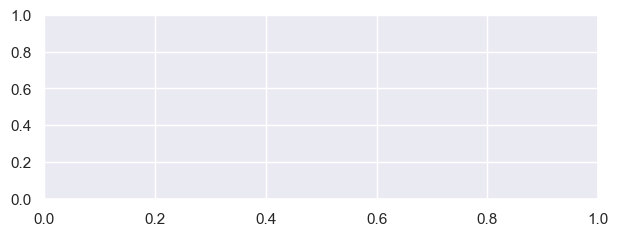

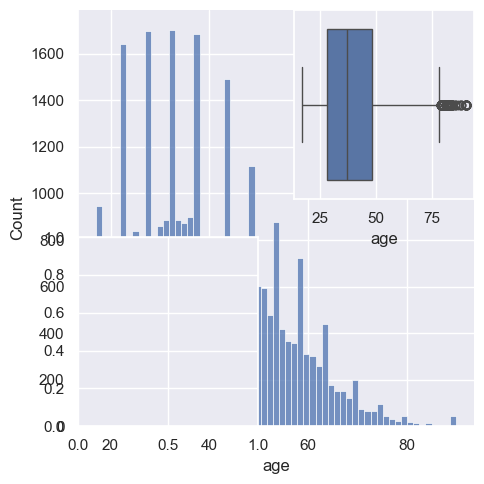

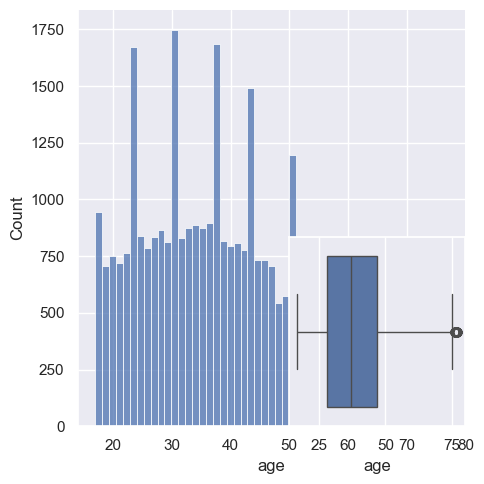

In [64]:
#compare 
plt.figure(figsize=(14,5))
plt.subplot(2,2,1)
sns.displot(x=data['age'])

plt.subplot(2,2,2)
sns.boxplot(x=data['age'])

plt.subplot(2,2,3)
sns.displot(x=new_data['age'])

plt.subplot(2,2,4)
sns.boxplot(x=new_data['age'])

            


In [65]:
#apply capping

#new_data_cap = data.copy() # create a copy of original data to apply capping on it

data['age'] = np.where(
    data['age'] > upper_limit, upper_limit,
    np.where(
     data['age'] < lower_limit, lower_limit,
     data['age']
     )
)

In [66]:
data.shape

(32537, 13)

In [67]:
data.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income,hour_per_week
0,78.0,3,9,6,9,1,4,0,0,4356,40.0,0,-0.035663
1,78.0,3,9,6,3,1,4,0,0,4356,18.0,0,-1.817489
2,66.0,3,10,6,9,4,2,0,0,4356,40.0,0,-0.035663
3,54.0,3,4,0,6,4,4,0,0,3900,40.0,0,-0.035663
4,41.0,3,10,5,9,3,4,0,0,3900,40.0,0,-0.035663


In [68]:
data.drop('hour_per_week', axis=1, inplace=True)

In [69]:
data.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income
0,78.0,3,9,6,9,1,4,0,0,4356,40.0,0
1,78.0,3,9,6,3,1,4,0,0,4356,18.0,0
2,66.0,3,10,6,9,4,2,0,0,4356,40.0,0
3,54.0,3,4,0,6,4,4,0,0,3900,40.0,0
4,41.0,3,10,5,9,3,4,0,0,3900,40.0,0


In [70]:
data.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income
0,78.0,3,9,6,9,1,4,0,0,4356,40.0,0
1,78.0,3,9,6,3,1,4,0,0,4356,18.0,0
2,66.0,3,10,6,9,4,2,0,0,4356,40.0,0
3,54.0,3,4,0,6,4,4,0,0,3900,40.0,0
4,41.0,3,10,5,9,3,4,0,0,3900,40.0,0


Percentile

In [71]:
data['capital_gain'].describe()

count    32537.000000
mean      1078.443741
std       7387.957424
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_gain, dtype: float64

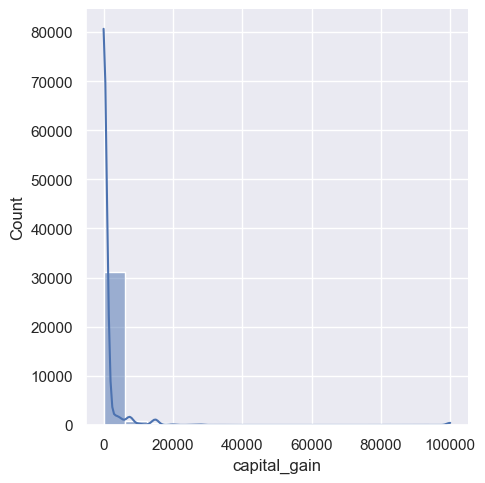

In [72]:
sns.displot(x=data['capital_gain'], kde=True)

<Axes: xlabel='capital_gain'>

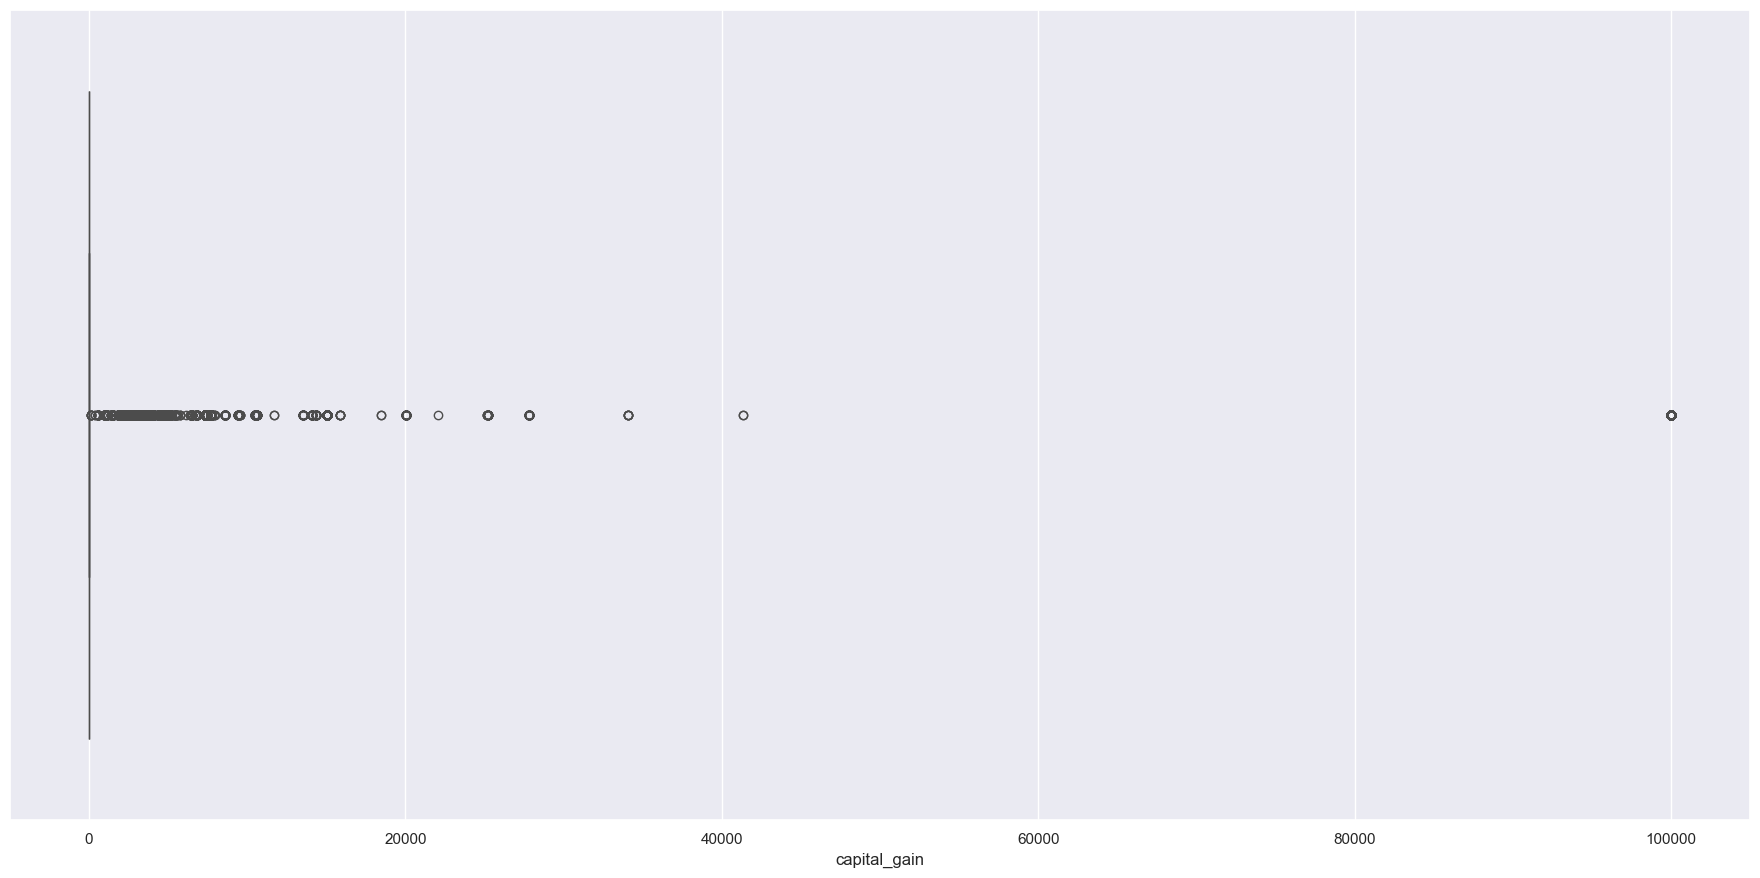

In [73]:
sns.boxplot(x=data['capital_gain'])

In [74]:
#set threshold symetric if upper in 0.99 than lowe wil be 0.01 also if upper is 0.95 than lower will be 0.05
upper_threshold = data['capital_gain'].quantile(0.99)
lower_threshold = data['capital_gain'].quantile(0.01)   
upper_threshold, lower_threshold

(np.float64(15024.0), np.float64(0.0))

In [75]:
#non-outlier data so we can keep boundaries Finding outliers  → strict > < (no =)
#Keeping normals   → >= <= (with =)
#new_data_cap = data.copy()
test_new_data = data [ (data['capital_gain'] <= upper_threshold ) & (data['capital_gain'] >= lower_threshold) ]

In [76]:
#trimming
data [ (data['capital_gain'] > upper_threshold ) | (data['capital_gain'] < lower_threshold) ]

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income
1519,54.0,4,15,2,9,0,4,1,99999,0,60.0,1
1520,52.0,3,9,2,3,0,1,1,99999,0,40.0,1
1521,53.0,4,9,2,11,0,4,1,99999,0,40.0,1
1522,52.0,3,13,2,3,0,4,1,99999,0,50.0,1
1523,46.0,3,15,2,9,0,4,1,99999,0,60.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1775,67.0,4,9,6,3,1,4,0,15831,0,40.0,1
1776,67.0,1,14,4,3,2,4,0,15831,0,72.0,1
1777,67.0,3,9,6,0,1,4,0,15831,0,16.0,1
1778,69.0,3,9,4,13,1,4,1,15831,0,40.0,1


In [77]:
test_new_data['capital_gain'].describe()

count    32276.000000
mean       517.916377
std       2173.425088
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      15024.000000
Name: capital_gain, dtype: float64

In [78]:
data['capital_gain'].describe()

count    32537.000000
mean      1078.443741
std       7387.957424
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_gain, dtype: float64

<Axes: xlabel='capital_gain'>

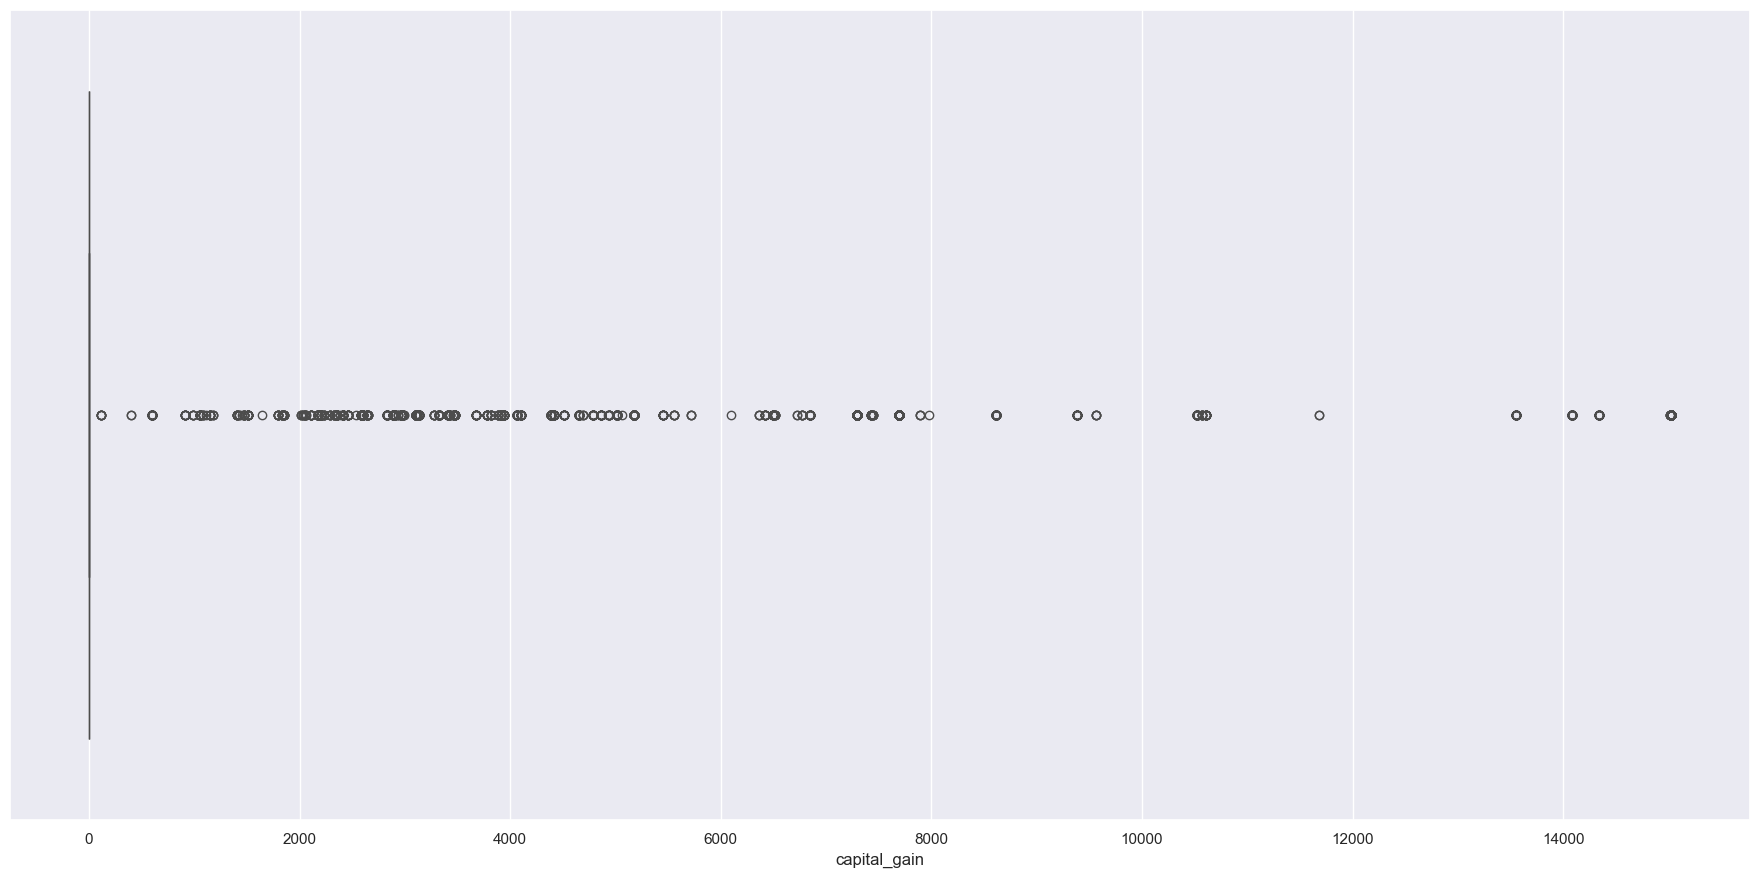

In [79]:
sns.boxplot(x=test_new_data['capital_gain']) 

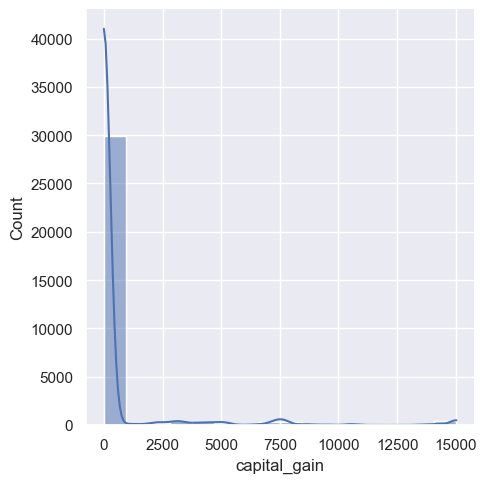

In [80]:
sns.displot(x=test_new_data['capital_gain'], kde=True)

In [81]:
#apply capping

new_data_cap = data.copy() # create a copy of original data to apply capping on it

new_data_cap['capital_gain'] = np.where(
    new_data_cap['capital_gain'] > upper_threshold, upper_threshold,
    np.where(
     new_data_cap['capital_gain'] < lower_threshold, lower_threshold,
     new_data_cap['capital_gain']
     )
)

In [82]:
new_data_cap.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income
0,78.0,3,9,6,9,1,4,0,0.0,4356,40.0,0
1,78.0,3,9,6,3,1,4,0,0.0,4356,18.0,0
2,66.0,3,10,6,9,4,2,0,0.0,4356,40.0,0
3,54.0,3,4,0,6,4,4,0,0.0,3900,40.0,0
4,41.0,3,10,5,9,3,4,0,0.0,3900,40.0,0


In [83]:
# Check value distribution
print(new_data_cap['capital_gain'].value_counts().head(10))
print(f"\nMax: {new_data_cap['capital_gain'].max()}")
print(f"Min: {new_data_cap['capital_gain'].min()}")
print(f"Non-zero values: {(new_data_cap['capital_gain'] > 0).sum()}")

capital_gain
0.0        29825
15024.0      608
7688.0       284
7298.0       246
5178.0        97
3103.0        97
4386.0        70
5013.0        69
8614.0        55
3325.0        53
Name: count, dtype: int64

Max: 15024.0
Min: 0.0
Non-zero values: 2712


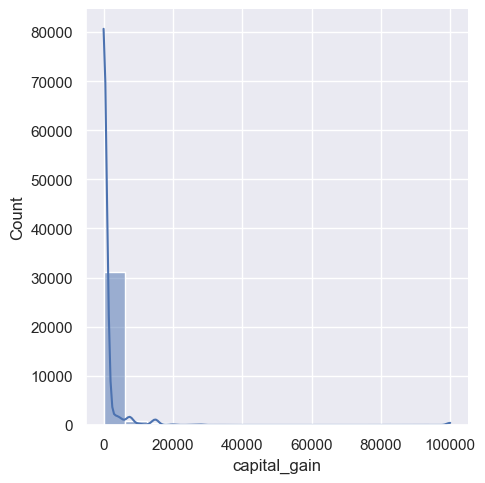

In [84]:
sns.displot(x=data['capital_gain'], kde=True)


<Axes: xlabel='capital_gain'>

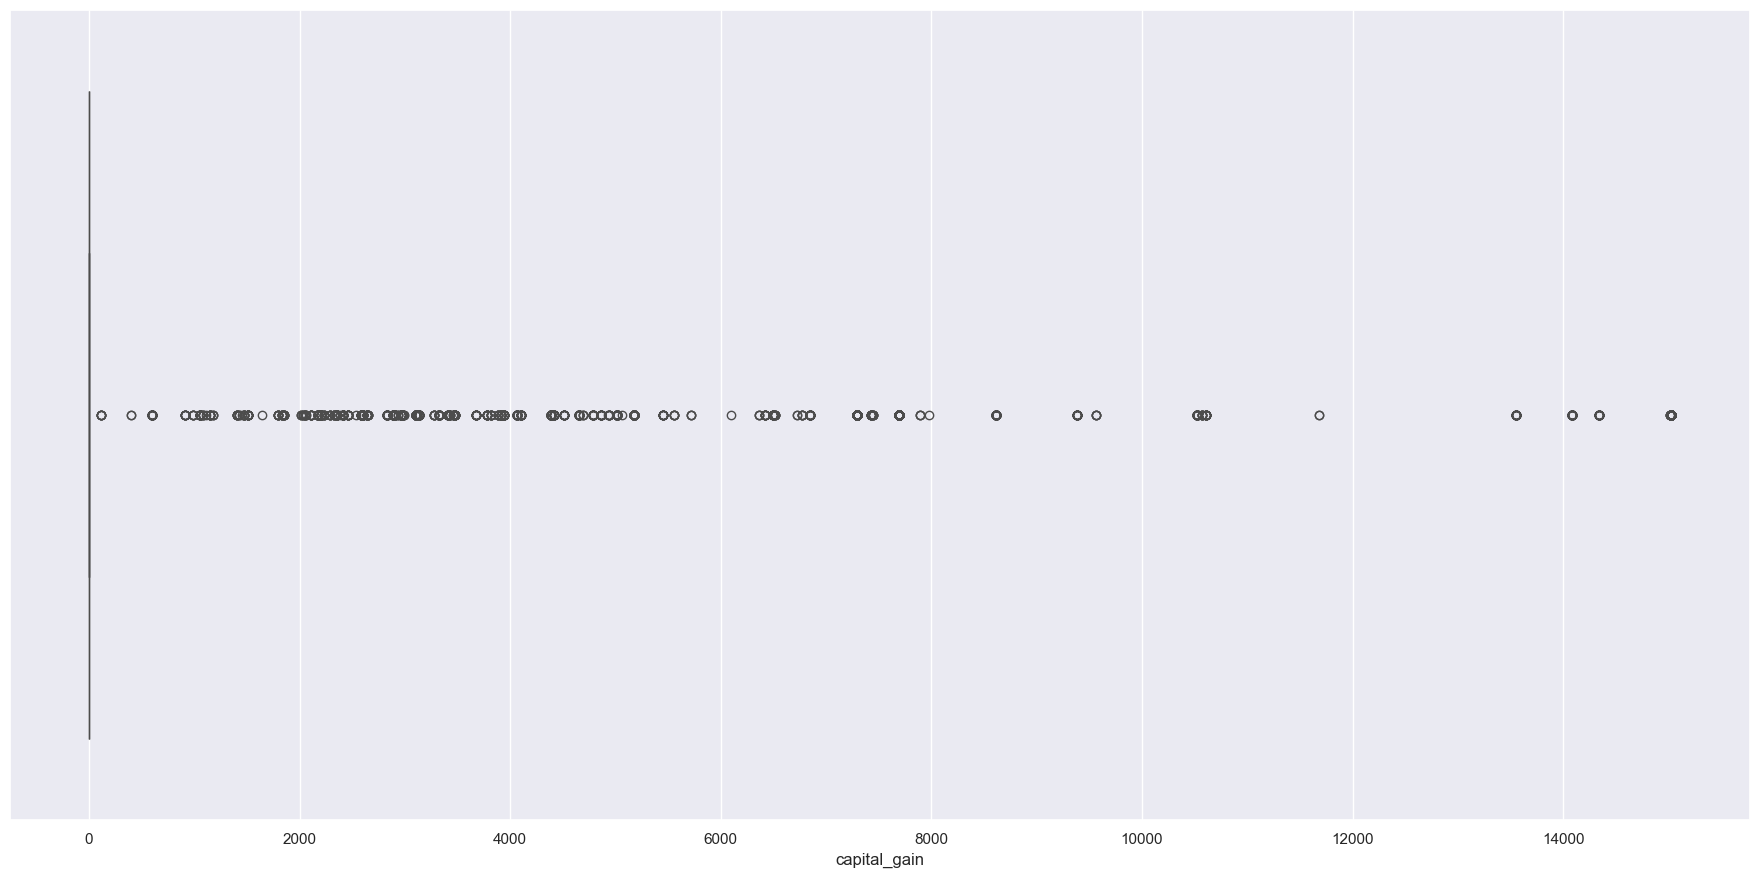

In [85]:
sns.boxplot(x=new_data_cap['capital_gain'])

In [86]:
new_data_cap['capital_gain'].describe()

count    32537.000000
mean       634.278913
std       2521.975203
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      15024.000000
Name: capital_gain, dtype: float64

Log Transformation

In [87]:
data['capital_loss'].describe()

count    32537.000000
mean        87.368227
std        403.101833
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital_loss, dtype: float64

In [88]:
# Step  - Apply log transformation
# log1p used because many values = 0
# log(0) is undefined!
# log1p = log(value + 1) solves this!

data['capital_loss'] = np.log1p(data['capital_loss'])

data['capital_loss'].describe()


count    32537.000000
mean         0.350563
std          1.585137
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          8.379539
Name: capital_loss, dtype: float64

<Axes: xlabel='capital_loss', ylabel='Count'>

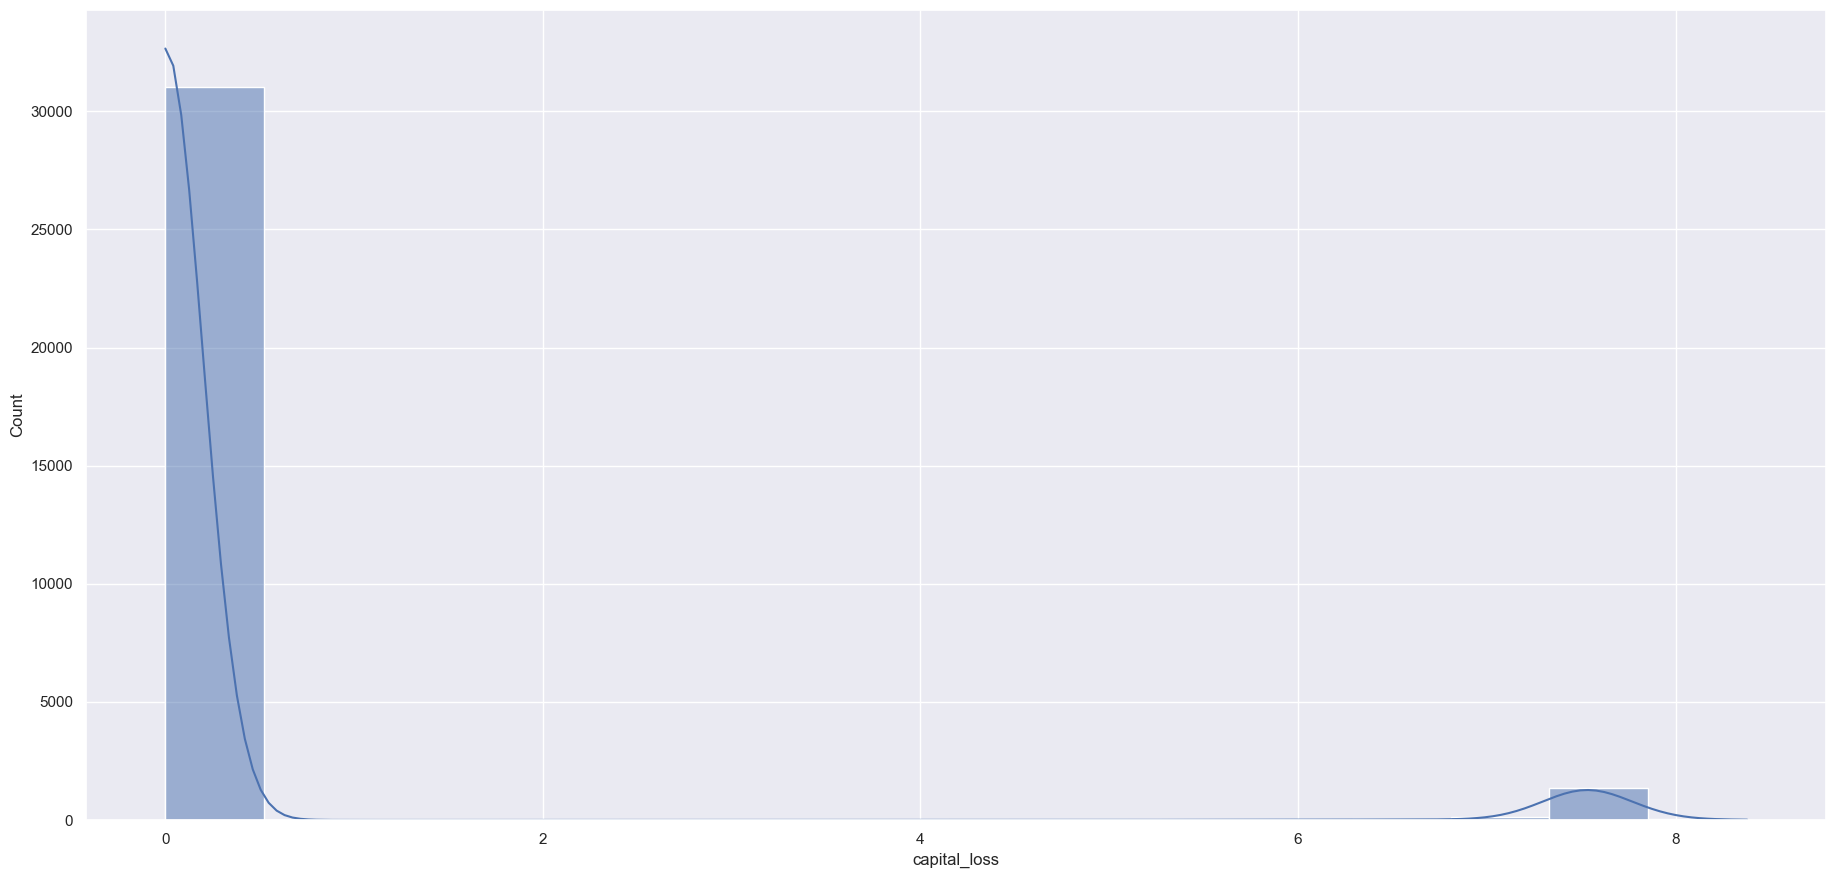

In [89]:
sns.histplot(data['capital_loss'], kde=True)  # ✅ histplot + kde

<Axes: xlabel='capital_loss'>

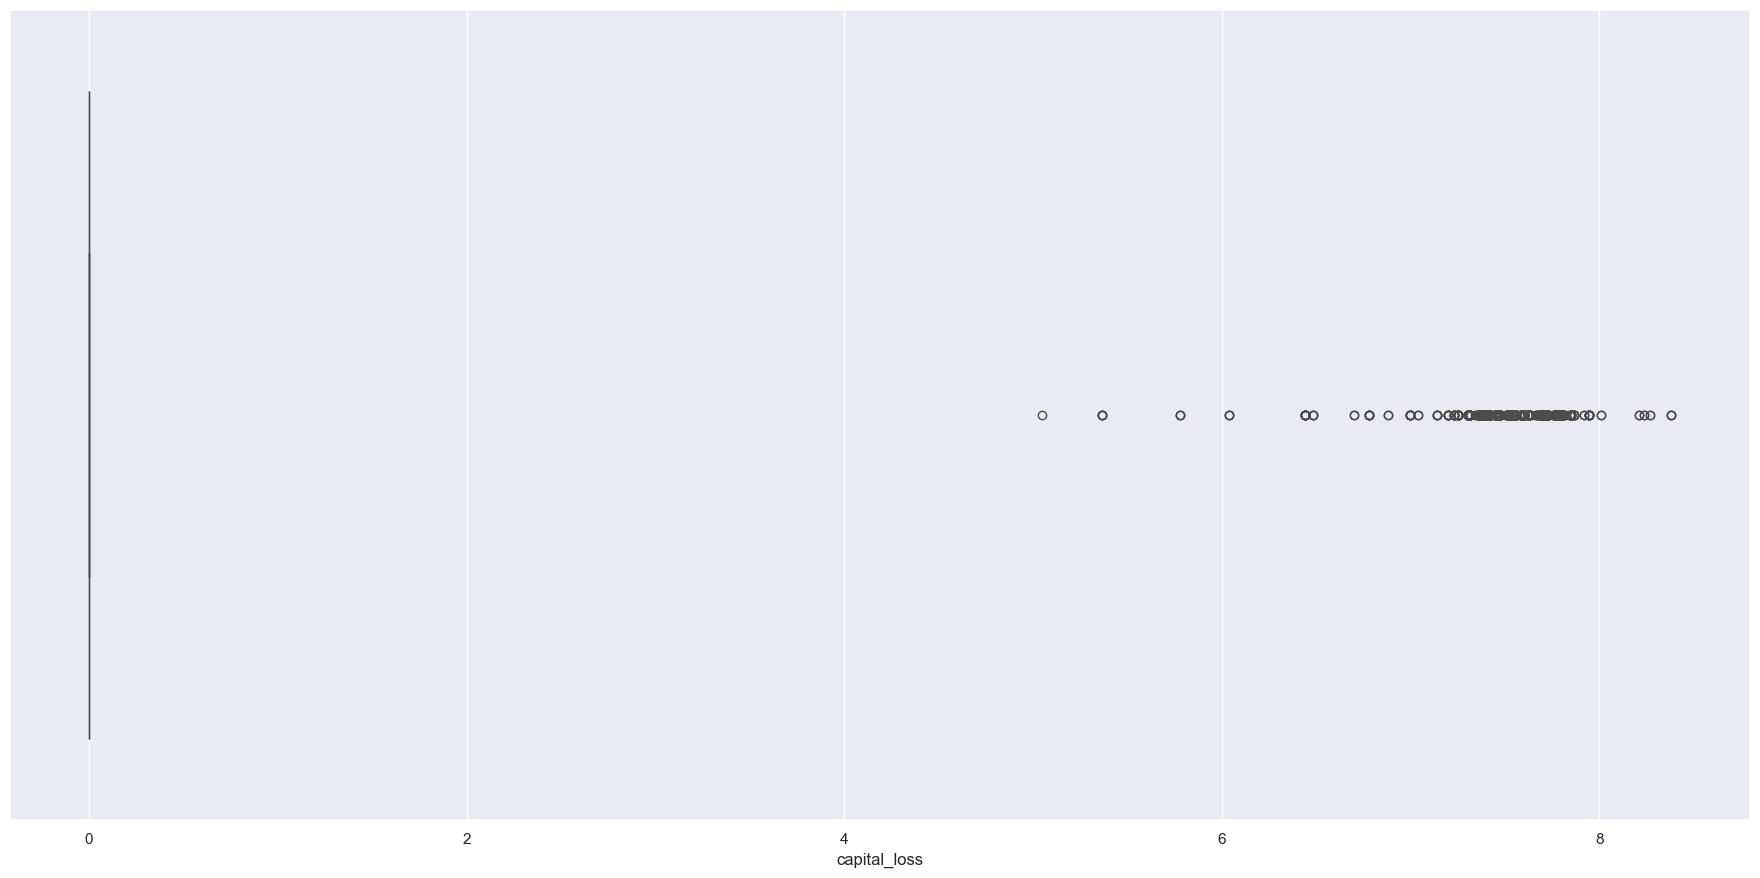

In [90]:
sns.boxplot(x=data['capital_loss'])

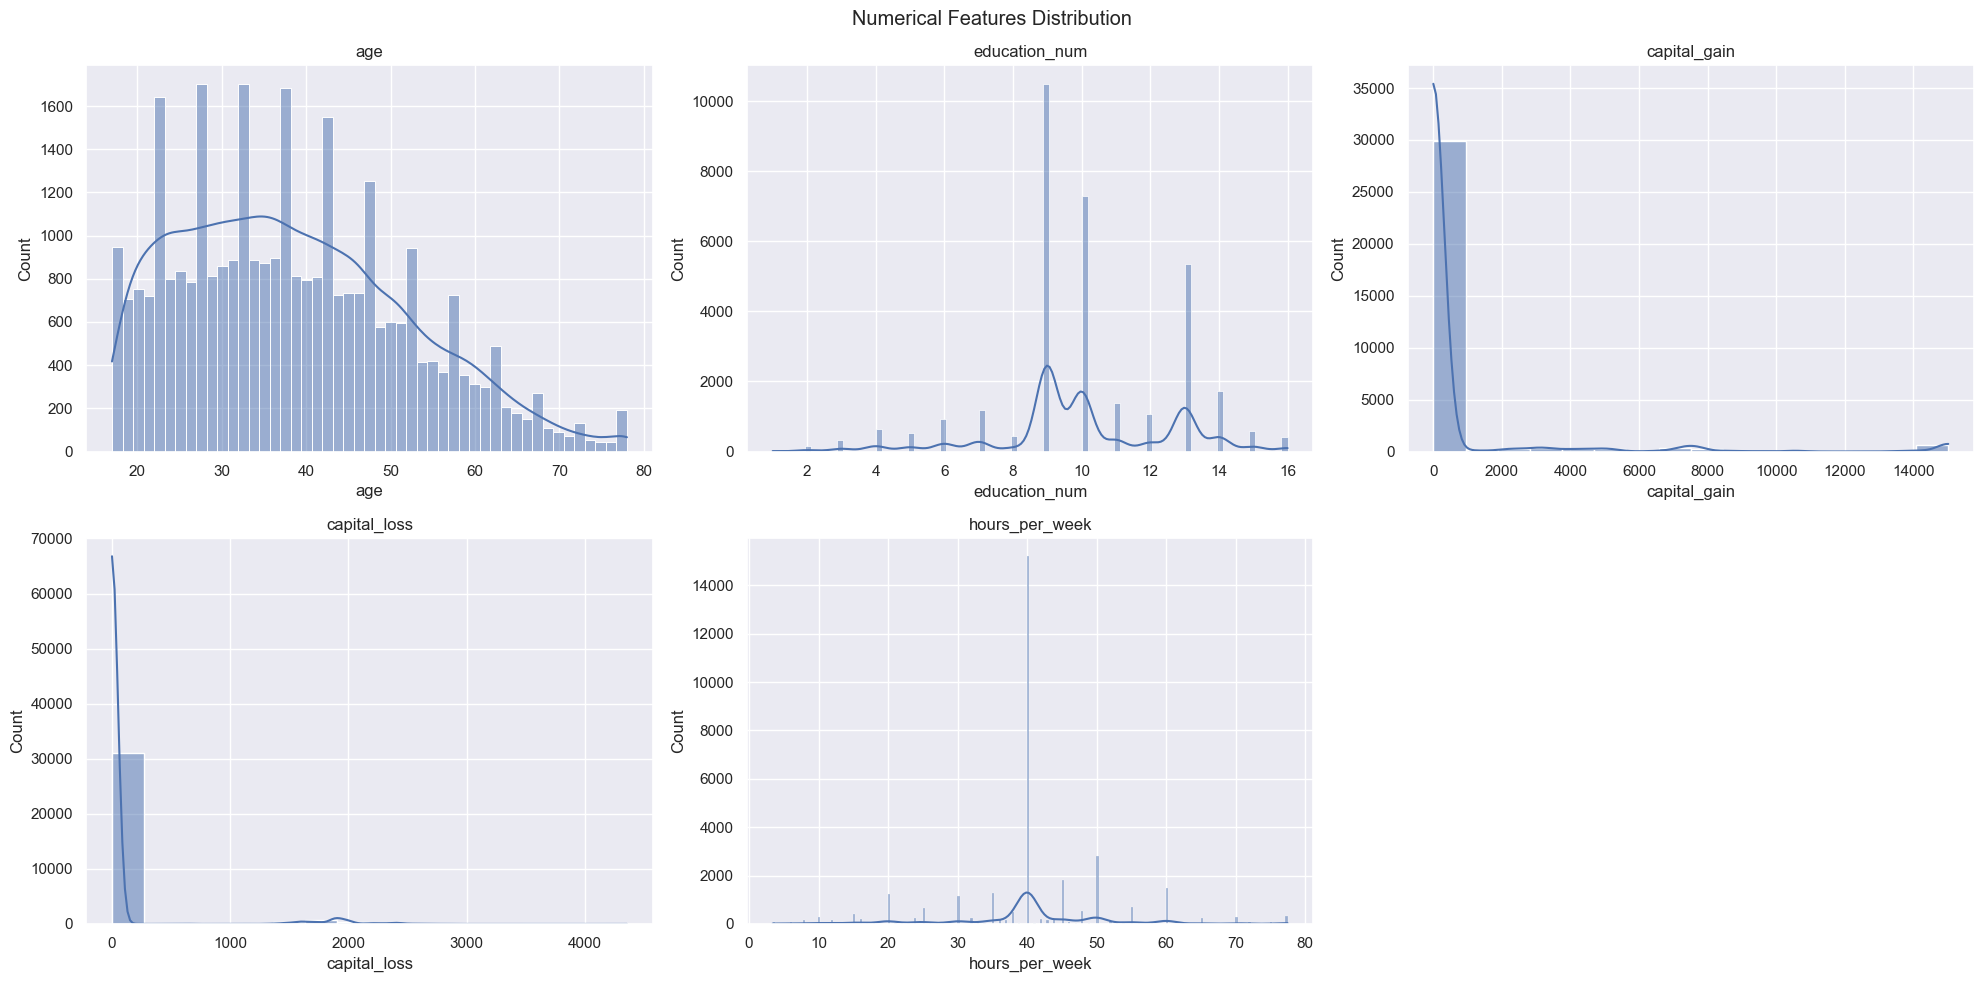

In [91]:
numerical_features = ['age', 'education_num',
                       'capital_gain', 'capital_loss',
                       'hours_per_week']

# ONE figure created ONCE outside loop!
plt.figure(figsize=(20,10))
plt.suptitle('Numerical Features Distribution')

for i in range(len(numerical_features)):
    plt.subplot(2, 3, i+1)          # position in grid
    sns.histplot(new_data_cap[numerical_features[i]], kde=True)
    plt.title(numerical_features[i]) # title for each
    plt.tight_layout()

plt.show()  # show ONCE at the end

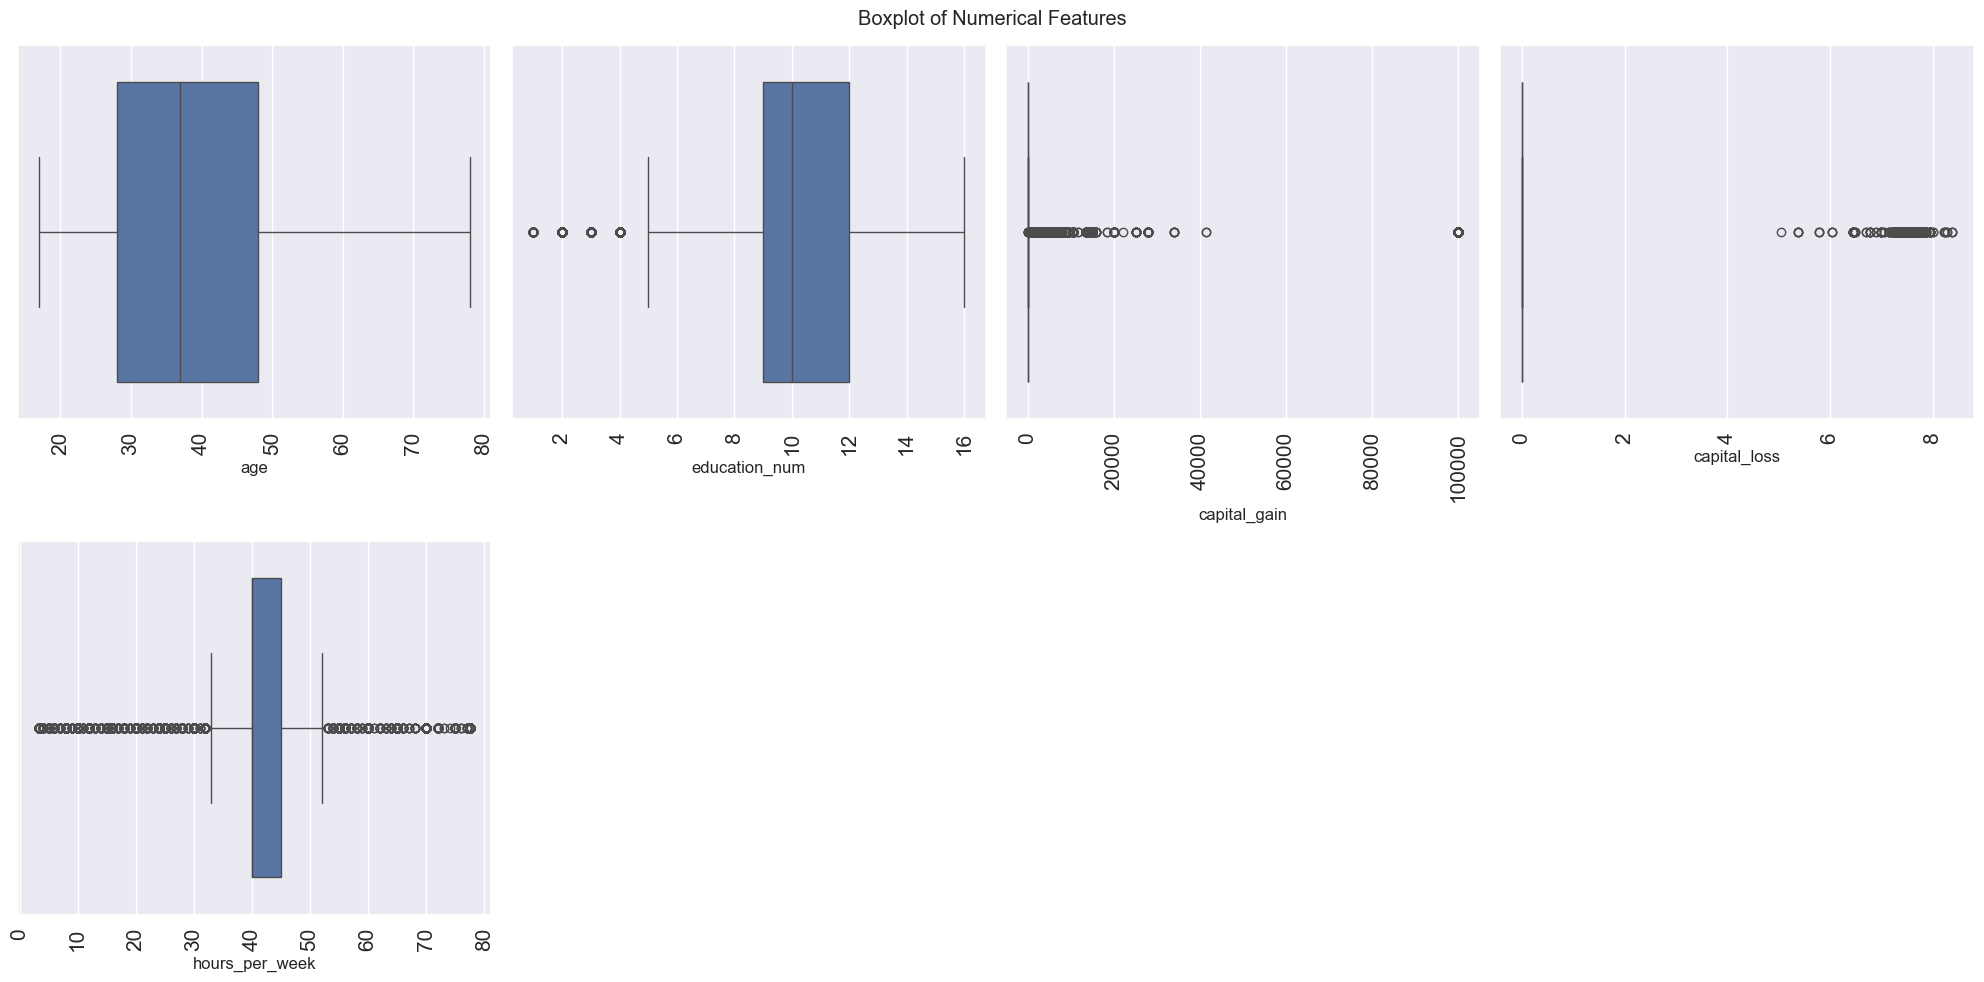

In [92]:
plt.suptitle('Boxplot of Numerical Features')
for i in range(0,len(numerical_features)):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=data[numerical_features[i]])
    plt.xticks(size=15,rotation=90)
    plt.tight_layout()  

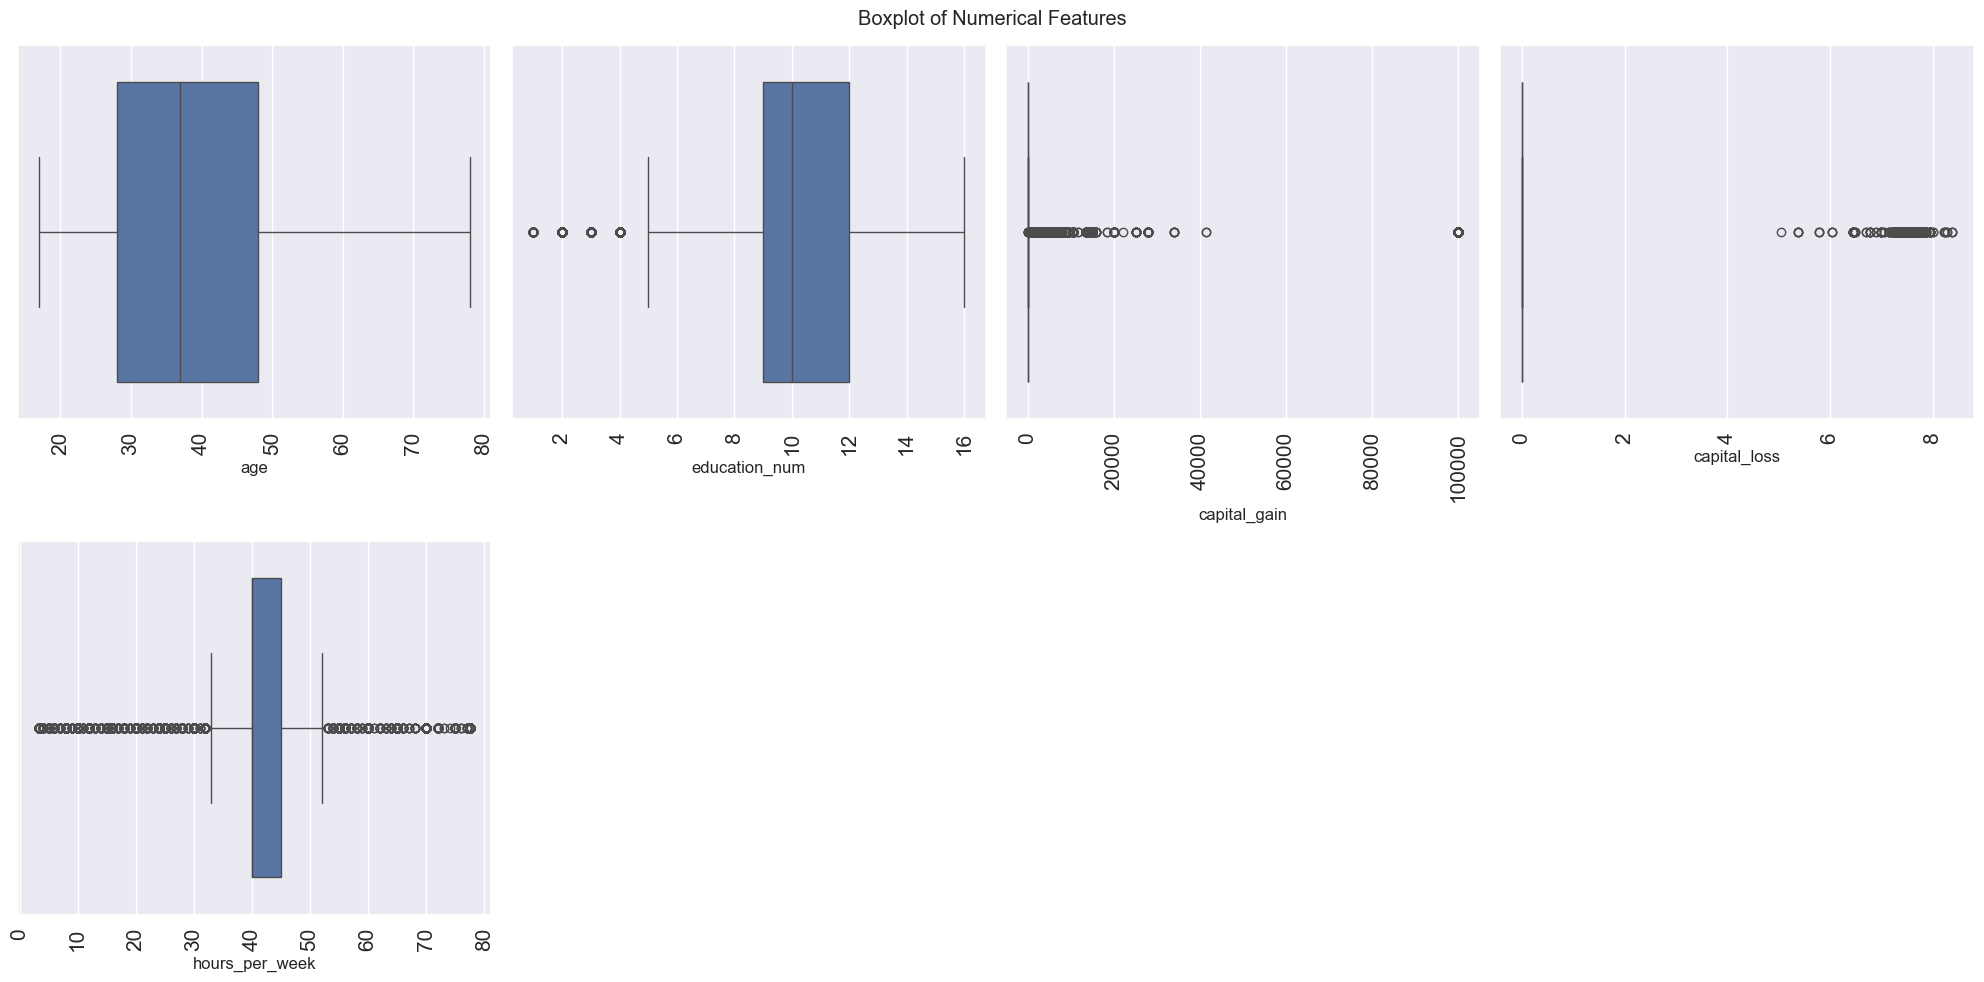

In [93]:
plt.suptitle('Boxplot of Numerical Features')
for i in range(0,len(numerical_features)):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=data[numerical_features[i]])
    plt.xticks(size=15,rotation=90)
    plt.tight_layout()  

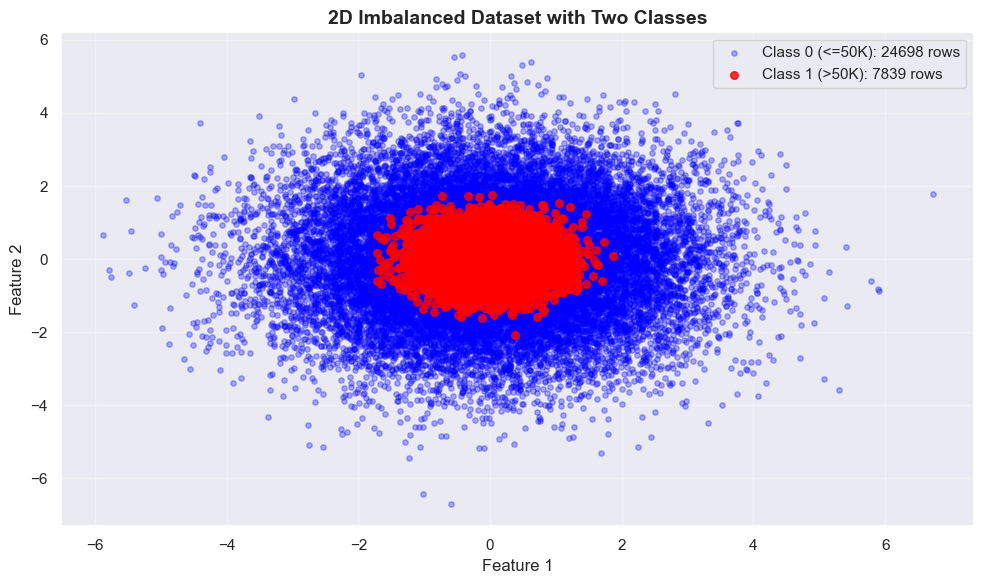

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# Get counts
income_counts = data['income'].value_counts()
class0_count = income_counts[0]  # 24698
class1_count = income_counts[1]  # 7839

np.random.seed(42)

# Class 0 - spread wide (majority)
x_class0 = np.random.randn(class0_count) * 1.5
y_class0 = np.random.randn(class0_count) * 1.5

# Class 1 - keep small cluster (minority)
x_class1 = np.random.randn(class1_count) * 0.5
y_class1 = np.random.randn(class1_count) * 0.5

plt.figure(figsize=(10,6))

# Plot class 0 first (background)
plt.scatter(
    x_class0, y_class0,
    c='blue',
    alpha=0.3,        # more transparent
    s=15,             # smaller dots
    label=f'Class 0 (<=50K): {class0_count} rows'
)

# Plot class 1 on top (foreground)
plt.scatter(
    x_class1, y_class1,
    c='red',
    alpha=0.8,        # more visible
    s=30,             # bigger dots
    label=f'Class 1 (>50K): {class1_count} rows'
)

plt.title('2D Imbalanced Dataset with Two Classes',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()